## **Librerías**

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional, List, Dict, Any, Union

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, fbeta_score,
    recall_score, precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier


import optuna
import warnings

warnings.filterwarnings("ignore")

## **Cargar datos**

In [2]:
# ============================================================
# CARGA DE DATOS
# ============================================================

ruta = "../data/processed/nacimientos_bogota_preprocesado.csv"

datos = pd.read_csv(
    ruta,
    sep=";",
    encoding="ISO-8859-1"
)

# ============================================================
# VERIFICACIÓN INICIAL
# ============================================================

print(f"Dimensiones: {datos.shape}")
datos.head()

Dimensiones: (384321, 47)


,COD_LOCALIDAD_NACIMIENTO,LOCALIDAD_NACIMIENTO,SIT_PARTO,SEXO,PESO_GRAMOS,PESO,BPN,TALLA_CENTIMETROS,ANO,ATENCION_PARTO_POR,...,ATENCION_PARTO_GRUPO,SEXO_AGRUPADO,MULTIPLICIDAD_AGRUPADA,PERTENENCIA_ETNICA_AGRUPADA,TIPO_DOC_MADRE_AGRUPADO,ESTADO_CONYUGAL_AGRUPADO,NIVEL_EDUCATIVO_MADRE_AGRUPADO,NIVEL_EDUCATIVO_PADRE_AGRUPADO,REGIMEN_SEGURIDAD_AGRUPADO,APGAR1_AGRUPADO
0,13,Teusaquillo,1.INSTITUCION DE SALUD,MASCULINO,3330.0,5.NORMAL(3000_4199),0,51.0,2020,1.MEDICO,...,Profesional de salud,MASCULINO,Simple,No pertenece a grupo etnico reconocido,Colombiana identificada,Casada,Media,Media,Contributivo,Alto
1,8,Kennedy,1.INSTITUCION DE SALUD,FEMENINO,2625.0,4.DEFICIT(2500_2999),0,47.0,2020,1.MEDICO,...,Profesional de salud,FEMENINO,Simple,No pertenece a grupo etnico reconocido,Extranjera,Sin pareja,Media,Media,No asegurado,Alto
2,9,Fontibón,1.INSTITUCION DE SALUD,FEMENINO,3150.0,5.NORMAL(3000_4199),0,49.0,2020,1.MEDICO,...,Profesional de salud,FEMENINO,Simple,No pertenece a grupo etnico reconocido,Colombiana identificada,Sin pareja,Basica,Media,Subsidiado,Alto
3,2,Chapinero,1.INSTITUCION DE SALUD,MASCULINO,4475.0,6.EXCESO(MAS4200),0,54.0,2020,1.MEDICO,...,Profesional de salud,MASCULINO,Simple,No pertenece a grupo etnico reconocido,Colombiana identificada,Union libre,Superior,Superior,Contributivo,Alto
4,12,Barrios Unidos,1.INSTITUCION DE SALUD,FEMENINO,2380.0,3.BAJO(1500_2499),1,48.0,2020,1.MEDICO,...,Profesional de salud,FEMENINO,Simple,No pertenece a grupo etnico reconocido,Colombiana identificada,Union libre,Media,Media,Contributivo,Alto


## **Clases**

## Infraestructura para modelamiento supervisado de clasificación binaria

### 1. RecortadorIQR: control robusto de valores extremos

La clase `RecortadorIQR` implementa una estrategia de winsorización basada en la regla de Tukey:

$$
LI = Q_1 - 1.5 \times IQR
$$

$$
LS = Q_3 + 1.5 \times IQR
$$

donde:

$$
IQR = Q_3 - Q_1
$$

Durante el método `fit()` se calculan los límites para cada variable numérica utilizando únicamente los datos de entrenamiento. Posteriormente, en `transform()`, cualquier observación por debajo del límite inferior es reemplazada por dicho límite, y cualquier observación por encima del límite superior es reemplazada por el límite superior correspondiente.

La principal ventaja de esta implementación es que evita fuga de información, ya que los límites son aprendidos exclusivamente sobre los datos disponibles en cada fold de entrenamiento durante validación cruzada.

---

### 2. Clase base para construcción del pipeline

La clase `_BaseSelectorV2` centraliza la lógica común necesaria para entrenar modelos de clasificación binaria.

Sus principales responsabilidades son:

* Verificar la existencia de todas las variables requeridas.
* Detectar variables repetidas.
* Crear la partición estratificada Train/Test.
* Construir el preprocesador.
* Configurar técnicas de remuestreo.
* Recuperar nombres de variables transformadas.

La clase almacena además atributos relacionados con:

* mejores hiperparámetros encontrados,
* mejor pipeline entrenado,
* mejor umbral de clasificación,
* métricas finales sobre el conjunto de prueba.

---

### 3. Separación Train/Test

La función `_crear_split_train_test()` realiza una partición estratificada:

$$
(X,y) \rightarrow
\left(
X_{train},
X_{test},
y_{train},
y_{test}
\right)
$$

manteniendo constante la prevalencia de la clase positiva.

El objetivo es garantizar que el conjunto de prueba permanezca completamente aislado durante todo el proceso de selección de hiperparámetros y validación cruzada.

De esta forma, cualquier evaluación posterior refleja una estimación honesta del desempeño fuera de muestra.

---

### 4. Construcción del preprocesador

La función `_construir_preprocesador()` crea un `ColumnTransformer` compuesto por tres bloques:

#### Variables numéricas

Pipeline:

1. Winsorización opcional (`RecortadorIQR`)
2. Estandarización (`StandardScaler`)

$$
Z =
\frac{X-\mu}{\sigma}
$$

---

#### Variables categóricas

Se aplica:

```python
OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)
```

Esto genera variables dummy evitando colinealidad perfecta.

---

#### Variables binarias o previamente transformadas

Se incorporan mediante:

```python
passthrough
```

sin modificaciones adicionales.

---

### 5. Manejo de desbalance de clases

La función `_crear_remuestreador()` permite construir dinámicamente distintos mecanismos de balanceo.

Métodos soportados:

* RandomUnderSampler
* RandomOverSampler
* SMOTE
* ADASYN
* BorderlineSMOTE
* SMOTETomek
* TomekLinks

Estos procedimientos buscan corregir situaciones donde:

$$
P(Y=1) \ll P(Y=0)
$$

como ocurre frecuentemente en problemas clínicos de baja prevalencia.

---

### 6. Recuperación de variables transformadas

Después de aplicar One-Hot Encoding, las variables originales dejan de existir.

La función `_nombres_features_transformadas()` reconstruye el nombre final de todas las variables utilizadas por el modelo:

* numéricas originales,
* variables dummy generadas,
* variables binarias pasadas directamente.

Esto resulta especialmente útil para interpretación, importancia de variables y explicabilidad.

---

## Utilidades de evaluación y explicabilidad

La clase `_ThresholdXAIUtils` incorpora herramientas complementarias para optimizar y analizar el desempeño predictivo.

---

### 7. Optimización del umbral de clasificación

Por defecto muchos modelos utilizan:

$$
threshold = 0.5
$$

Sin embargo, en contextos clínicos este valor suele ser subóptimo.

La función `_buscar_mejor_threshold()` evalúa múltiples umbrales y selecciona aquel que maximiza una métrica objetivo.

Las métricas consideradas son:

#### F1

$$
F1 =
\frac{
2 \cdot Precision \cdot Recall
}{
Precision + Recall
}
$$

#### F2

$$
F2 =
\frac{
5 \cdot Precision \cdot Recall
}{
4 \cdot Precision + Recall
}
$$

La métrica F2 otorga mayor peso a la sensibilidad, aspecto especialmente relevante en detección temprana de eventos clínicos.

---

### 8. Evaluación en conjunto de prueba

La función `_evaluar_en_test_con_threshold()` calcula:

* AUC ROC
* Average Precision
* F1
* F2
* Sensibilidad
* Precisión
* Brier Score

Además genera:

* Reporte de clasificación.
* Matriz de confusión.
* Curva ROC.

La evaluación siempre se realiza sobre el conjunto de prueba completamente aislado.

---

### 9. Curvas de desempeño según threshold

La función `graficar_metricas_vs_threshold_test()` permite estudiar cómo cambian:

* F1
* F2
* Sensibilidad
* Precisión

al modificar el umbral de clasificación.

Esto facilita seleccionar un punto de operación clínicamente adecuado.

---

### 10. Curva Precision-Recall

La función `graficar_precision_recall_test()` construye la curva:

$$
Precision
\quad vs \quad
Recall
$$

y calcula el área bajo dicha curva mediante:

$$
AP = Average\ Precision
$$

Esta métrica suele ser más informativa que AUC cuando existe fuerte desbalance entre clases.

---

### 11. Calibración probabilística

La función `graficar_calibracion_test()` evalúa si las probabilidades emitidas por el modelo corresponden a riesgos observados.

Un modelo perfectamente calibrado cumple:

$$
P(Y=1 \mid \hat p = p)
======================

p
$$

También se calcula el:

$$
Brier\ Score
$$

como medida global de calidad probabilística.

---

### 12. Evaluación de sobreajuste

La función `evaluar_train_vs_test()` compara métricas obtenidas en:

* Train Development
* Test

Diferencias importantes entre ambos conjuntos pueden indicar sobreajuste.

---

### 13. Importancia de variables por permutación

Finalmente, `importancia_permutacion_test()` implementa Permutation Importance.

La idea consiste en:

1. Permutar aleatoriamente una variable.
2. Recalcular la métrica de desempeño.
3. Medir la pérdida producida.

Variables cuya permutación genera una mayor caída en desempeño son consideradas más relevantes para la predicción.

Este procedimiento es agnóstico al modelo y permite interpretar modelos complejos manteniendo la evaluación exclusivamente sobre datos no vistos.


In [3]:
# ============================================================
# TRANSFORMER: RECORTADOR IQR
# ============================================================

class RecortadorIQR(BaseEstimator, TransformerMixin):
    """
    Winsoriza variables numéricas usando regla de Tukey:
    [Q1 - 1.5*IQR, Q3 + 1.5*IQR].

    Importante:
    - Los límites se aprenden únicamente en fit().
    - En CV, fit() ocurre solo sobre el fold de entrenamiento.
    - Esto evita leakage.
    """

    def __init__(self, feature_names: Optional[List[str]] = None):
        self.feature_names = feature_names
        self.bounds_ = {}

    def fit(self, X, y=None):
        X_df = (
            pd.DataFrame(X, columns=self.feature_names)
            if self.feature_names is not None
            else pd.DataFrame(X)
        )

        self.bounds_ = {}

        for col in X_df.columns:
            s = pd.to_numeric(X_df[col], errors="coerce")
            q1 = s.quantile(0.25)
            q3 = s.quantile(0.75)
            iqr = q3 - q1

            low = q1 - 1.5 * iqr
            high = q3 + 1.5 * iqr

            self.bounds_[col] = (low, high)

        return self

    def transform(self, X):
        X_df = (
            pd.DataFrame(X, columns=self.feature_names)
            if self.feature_names is not None
            else pd.DataFrame(X)
        )

        for col, (low, high) in self.bounds_.items():
            if col in X_df.columns:
                X_df[col] = pd.to_numeric(
                    X_df[col],
                    errors="coerce"
                ).clip(lower=low, upper=high)

        return X_df.values


# ============================================================
# CLASE BASE V2
# ============================================================

class _BaseSelectorV2:
    """
    Clase base para modelos supervisados binarios.

    Responsabilidades:
    - Validación de columnas.
    - Separación train_dev/test antes de cualquier transformación.
    - Construcción de preprocesador.
    - Construcción de remuestreadores.
    - Recuperación de nombres de variables transformadas.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        target: str,
        features: List[str],
        numeric_vars: Optional[List[str]] = None,
        dummy_vars: Optional[List[str]] = None,
        dropna: bool = True,
        clip_outliers: bool = False,
        test_size: float = 0.2,
        random_state: int = 42,
    ):

        self.df = df.copy()
        self.target = target
        self.features = features
        self.numeric_vars = numeric_vars or []
        self.dummy_vars = dummy_vars or []
        self.dropna = dropna
        self.clip_outliers = clip_outliers
        self.test_size = test_size
        self.random_state = random_state

        self.best_params: Optional[Dict[str, Any]] = None
        self.best_trial_value_: Optional[float] = None
        self.best_pipeline_: Optional[ImbPipeline] = None
        self.best_threshold_: Optional[float] = None
        self.test_metrics_: Optional[Dict[str, Any]] = None

        self._validar_columnas()
        self._crear_split_train_test()

    def _validar_columnas(self):
        """
        Verifica que target, features, numéricas y categóricas existan en df.
        """

        columnas_requeridas = list(
            set(
                [self.target]
                + self.features
                + self.numeric_vars
                + self.dummy_vars
            )
        )

        faltantes = [
            c for c in columnas_requeridas
            if c not in self.df.columns
        ]

        if len(faltantes) > 0:
            raise ValueError(
                f"Las siguientes columnas no existen en df: {faltantes}"
            )

        features_duplicadas = pd.Series(self.features).duplicated()

        if features_duplicadas.any():
            duplicadas = pd.Series(self.features)[features_duplicadas].tolist()
            raise ValueError(
                f"Hay variables repetidas en features: {duplicadas}"
            )

    def _crear_split_train_test(self):
        """
        Crea partición estratificada train_dev/test.
        El test queda completamente aislado.
        """

        dfm = self.df[self.features + [self.target]].copy()

        if self.dropna:
            dfm = dfm.dropna()

        X = dfm.drop(columns=[self.target])
        y = dfm[self.target].astype(int)

        self.X_train_dev, self.X_test, self.y_train_dev, self.y_test = train_test_split(
            X,
            y,
            test_size=self.test_size,
            stratify=y,
            random_state=self.random_state
        )

        self.passthrough_vars_ = [
            c for c in self.X_train_dev.columns
            if c not in self.numeric_vars
            and c not in self.dummy_vars
        ]

        self.prevalencia_global_ = float(y.mean())
        self.prevalencia_train_dev_ = float(self.y_train_dev.mean())
        self.prevalencia_test_ = float(self.y_test.mean())

        print("\n=== SPLIT INICIAL ===")
        print(f"Train_dev: {self.X_train_dev.shape}")
        print(f"Test     : {self.X_test.shape}")
        print(f"Prevalencia global    : {self.prevalencia_global_:.4f}")
        print(f"Prevalencia train_dev : {self.prevalencia_train_dev_:.4f}")
        print(f"Prevalencia test      : {self.prevalencia_test_:.4f}")

    def _construir_preprocesador(self) -> ColumnTransformer:
        """
        Construye preprocesador:
        - Numéricas: RecortadorIQR opcional + StandardScaler.
        - Categóricas: OneHotEncoder.
        - Passthrough: variables ya preparadas/binarias.
        """

        pasos_num = []

        if self.clip_outliers and len(self.numeric_vars) > 0:
            pasos_num.append(
                ("recorte_iqr", RecortadorIQR(feature_names=self.numeric_vars))
            )

        pasos_num.append(
            ("escalador", StandardScaler(with_mean=True, with_std=True))
        )

        pipe_num = Pipeline(pasos_num)

        try:
            cat_pipe = OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            )
        except TypeError:
            cat_pipe = OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse=False
            )

        preprocesador = ColumnTransformer(
            transformers=[
                ("num", pipe_num, self.numeric_vars),
                ("cat", cat_pipe, self.dummy_vars),
                ("passthrough", "passthrough", self.passthrough_vars_)
            ],
            remainder="drop"
        )

        return preprocesador

    def _crear_remuestreador(
        self,
        nombre: str,
        proporcion: Optional[float]
    ) -> Union[str, BaseEstimator]:
        """
        Crea remuestreador compatible con imblearn.Pipeline.
        """

        if nombre == "none":
            return "passthrough"

        if nombre == "tomelinks":
            return TomekLinks()

        prop = 1.0 if proporcion is None else float(proporcion)

        if nombre == "undersample":
            return RandomUnderSampler(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        if nombre == "oversample":
            return RandomOverSampler(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        if nombre == "smote":
            return SMOTE(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        if nombre == "adasyn":
            return ADASYN(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        if nombre == "smotetomek":
            return SMOTETomek(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        if nombre == "borderlinesmote":
            return BorderlineSMOTE(
                sampling_strategy=prop,
                random_state=self.random_state
            )

        raise ValueError(f"Método de remuestreo desconocido: {nombre}")

    def _nombres_features_transformadas(
        self,
        preprocesador: ColumnTransformer
    ) -> List[str]:
        """
        Recupera nombres de variables después del preprocesamiento.
        """

        nombres = []

        nombres.extend(self.numeric_vars.copy())

        if len(self.dummy_vars) > 0:
            cat_encoder = preprocesador.named_transformers_["cat"]
            cat_out = cat_encoder.get_feature_names_out(self.dummy_vars)
            nombres.extend(list(cat_out))

        nombres.extend(self.passthrough_vars_)

        return nombres


# ============================================================
# UTILIDADES COMUNES: THRESHOLD, EVALUACIÓN Y XAI
# ============================================================

class _ThresholdXAIUtils:
    """
    Mixin con utilidades comunes para:
    - búsqueda de threshold,
    - evaluación,
    - curvas,
    - calibración,
    - permutation importance.
    """

    def _buscar_mejor_threshold(
        self,
        y_true,
        proba,
        thresholds,
        metrica_objetivo: str = "f2"
    ):

        mejor_score = -np.inf
        mejor_threshold = 0.5

        mejor_f1 = 0.0
        mejor_f2 = 0.0
        mejor_recall = 0.0
        mejor_precision = 0.0

        for threshold in thresholds:
            y_pred = (proba >= threshold).astype(int)

            f1 = f1_score(y_true, y_pred, zero_division=0)
            f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)
            precision = precision_score(y_true, y_pred, zero_division=0)

            score = f2 if metrica_objetivo == "f2" else f1

            if score > mejor_score:
                mejor_score = score
                mejor_threshold = threshold
                mejor_f1 = f1
                mejor_f2 = f2
                mejor_recall = recall
                mejor_precision = precision

        return {
            "threshold": mejor_threshold,
            "score_objetivo": mejor_score,
            "f1": mejor_f1,
            "f2": mejor_f2,
            "sensibilidad": mejor_recall,
            "precision": mejor_precision
        }

    def _metricas_desde_proba(self, y_true, proba, threshold: float):

        pred = (proba >= threshold).astype(int)

        return {
            "AUC": roc_auc_score(y_true, proba),
            "AveragePrecision": average_precision_score(y_true, proba),
            "F1": f1_score(y_true, pred, zero_division=0),
            "F2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "Sensibilidad": recall_score(y_true, pred, zero_division=0),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Brier": brier_score_loss(y_true, proba)
        }

    def _evaluar_en_test_con_threshold(
        self,
        pipe,
        model_name: str,
        threshold: float
    ):

        proba_test = pipe.predict_proba(self.X_test)[:, 1]
        preds = (proba_test >= threshold).astype(int)

        metricas = self._metricas_desde_proba(
            self.y_test,
            proba_test,
            threshold
        )

        self.test_metrics_ = {
            "Modelo": model_name,
            "Threshold": threshold,
            **metricas
        }

        print(f"\n=== TEST: {model_name} ===")
        print(f"Threshold usado: {threshold:.3f}")
        print(pd.Series(metricas).round(4))

        print("\n--- Reporte de clasificación ---")
        print(classification_report(
            self.y_test,
            preds,
            digits=3,
            zero_division=0
        ))

        cm = confusion_matrix(self.y_test, preds)

        print("Matriz de confusión:\n", cm)

        fpr, tpr, _ = roc_curve(self.y_test, proba_test)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("1 - Especificidad")
        plt.ylabel("Sensibilidad")
        plt.title(f"Curva ROC - TEST ({model_name})")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5.2, 4.4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No BPN", "BPN"],
            yticklabels=["No BPN", "BPN"]
        )
        plt.title(f"Matriz de confusión - {model_name} - threshold={threshold:.2f}")
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.tight_layout()
        plt.show()

        return self.test_metrics_

    def graficar_metricas_vs_threshold_test(
        self,
        thresholds=np.arange(0.01, 0.91, 0.01)
    ):

        assert self.best_pipeline_ is not None, "Primero ejecuta entrenar_y_evaluar()."

        proba = self.best_pipeline_.predict_proba(self.X_test)[:, 1]
        threshold_opt = getattr(self, "best_threshold_", 0.5)

        resultados = []

        for t in thresholds:
            pred = (proba >= t).astype(int)

            resultados.append({
                "threshold": t,
                "F1": f1_score(self.y_test, pred, zero_division=0),
                "F2": fbeta_score(self.y_test, pred, beta=2, zero_division=0),
                "Sensibilidad": recall_score(self.y_test, pred, zero_division=0),
                "Precision": precision_score(self.y_test, pred, zero_division=0)
            })

        df_thr = pd.DataFrame(resultados)

        plt.figure(figsize=(9, 5))
        plt.plot(df_thr["threshold"], df_thr["F1"], label="F1")
        plt.plot(df_thr["threshold"], df_thr["F2"], label="F2")
        plt.plot(df_thr["threshold"], df_thr["Sensibilidad"], label="Sensibilidad")
        plt.plot(df_thr["threshold"], df_thr["Precision"], label="Precisión")
        plt.axvline(
            threshold_opt,
            linestyle="--",
            label=f"Threshold CV={threshold_opt:.2f}"
        )
        plt.xlabel("Threshold")
        plt.ylabel("Métrica")
        plt.title("Métricas según threshold - TEST")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return df_thr

    def graficar_precision_recall_test(self):

        assert self.best_pipeline_ is not None, "Primero ejecuta entrenar_y_evaluar()."

        proba = self.best_pipeline_.predict_proba(self.X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(self.y_test, proba)
        ap = average_precision_score(self.y_test, proba)

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AP={ap:.3f}")
        plt.xlabel("Sensibilidad / Recall")
        plt.ylabel("Precisión")
        plt.title("Curva Precision-Recall - TEST")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def graficar_calibracion_test(self, n_bins: int = 10):

        assert self.best_pipeline_ is not None, "Primero ejecuta entrenar_y_evaluar()."

        proba = self.best_pipeline_.predict_proba(self.X_test)[:, 1]

        frac_pos, mean_pred = calibration_curve(
            self.y_test,
            proba,
            n_bins=n_bins,
            strategy="quantile"
        )

        brier = brier_score_loss(self.y_test, proba)

        plt.figure(figsize=(6, 5))
        plt.plot(mean_pred, frac_pos, marker="o", label=f"Brier={brier:.3f}")
        plt.plot([0, 1], [0, 1], "--", label="Calibración perfecta")
        plt.xlabel("Probabilidad media predicha")
        plt.ylabel("Proporción observada de BPN")
        plt.title("Curva de calibración - TEST")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def evaluar_train_vs_test(self):

        assert self.best_pipeline_ is not None, "Primero ejecuta entrenar_y_evaluar()."

        threshold = getattr(self, "best_threshold_", 0.5)

        resultados = []

        for nombre, X, y in [
            ("TRAIN_DEV", self.X_train_dev, self.y_train_dev),
            ("TEST", self.X_test, self.y_test)
        ]:

            proba = self.best_pipeline_.predict_proba(X)[:, 1]
            metricas = self._metricas_desde_proba(y, proba, threshold)

            resultados.append({
                "Conjunto": nombre,
                "Threshold": threshold,
                **metricas
            })

        df_res = pd.DataFrame(resultados)

        print("\n=== COMPARACIÓN TRAIN_DEV vs TEST ===")
        print(df_res.round(4))

        df_plot = df_res.set_index("Conjunto")

        df_plot[[
            "AUC",
            "AveragePrecision",
            "F1",
            "F2",
            "Sensibilidad",
            "Precision"
        ]].plot(kind="bar", figsize=(11, 5))

        plt.title(f"Comparación TRAIN_DEV vs TEST - threshold={threshold:.3f}")
        plt.ylabel("Métrica")
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        return df_res

    def importancia_permutacion_test(
        self,
        n_repeats: int = 10,
        scoring: str = "f1",
        top_n: int = 20
    ):

        assert self.best_pipeline_ is not None, "Primero ejecuta entrenar_y_evaluar()."

        result = permutation_importance(
            self.best_pipeline_,
            self.X_test,
            self.y_test,
            n_repeats=n_repeats,
            random_state=self.random_state,
            scoring=scoring,
            n_jobs=-1
        )

        imp = pd.DataFrame({
            "variable": self.X_test.columns,
            "importance_mean": result.importances_mean,
            "importance_std": result.importances_std
        }).sort_values("importance_mean", ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=imp.head(top_n),
            x="importance_mean",
            y="variable"
        )
        plt.title(f"Permutation Importance - TEST - scoring={scoring}")
        plt.xlabel("Disminución media de la métrica")
        plt.ylabel("Variable")
        plt.tight_layout()
        plt.show()

        self.permutation_importance_ = imp

        return imp

## **Regresión Logística Optimizada con Optuna**

## Objetivo general

La clase `OptunaLogRegSelectorV2` tiene como finalidad construir un flujo completo de modelamiento para clasificación binaria basado en Regresión Logística, incorporando:

* Optimización automática de hiperparámetros.
* Manejo de desbalance de clases.
* Optimización del umbral de decisión.
* Validación cruzada estratificada.
* Evaluación final sobre un conjunto de prueba independiente.
* Interpretación mediante coeficientes y Odds Ratios.
* Herramientas de explicabilidad y diagnóstico.

---

# 1. Estructura general de la clase

La clase hereda de dos componentes previamente definidos:

```python
class OptunaLogRegSelectorV2(
    _ThresholdXAIUtils,
    _BaseSelectorV2
)
```

Por tanto hereda automáticamente:

### Desde `_BaseSelectorV2`

* Train/Test split estratificado.
* Preprocesamiento.
* One-Hot Encoding.
* Winsorización opcional.
* Escalamiento.
* Remuestreo.

### Desde `_ThresholdXAIUtils`

* Búsqueda de umbral óptimo.
* Curvas ROC.
* Curvas Precision-Recall.
* Curvas de calibración.
* Permutation Importance.
* Comparación Train vs Test.

---

# 2. Constructor

El constructor inicializa estructuras para almacenar información interpretativa del modelo.

```python
self.coef_series_
self.odds_ratios_
self.tabla_coeficientes_
self.intercepto_
```

Estas variables se llenan únicamente después del entrenamiento final.

---

# 3. Optimización mediante Optuna

La función principal de búsqueda es:

```python
optimizar()
```

Su objetivo es encontrar automáticamente la combinación de hiperparámetros que maximiza una métrica objetivo.

---

## Hiperparámetros optimizados

### Penalización

```python
penalty = ["l1", "l2"]
```

#### L1 (Lasso)

[
\lambda \sum |\beta_j|
]

Favorece selección automática de variables.

---

#### L2 (Ridge)

[
\lambda \sum \beta_j^2
]

Reduce varianza manteniendo todas las variables.

---

### Parámetro de regularización

```python
C
```

Optuna explora:

[
C \in [10^{-3},20]
]

recordando que:

[
C=\frac{1}{\lambda}
]

Valores pequeños:

* mayor regularización.

Valores grandes:

* menor regularización.

---

### Solver

Se optimiza entre:

```python
liblinear
saga
```

Ambos compatibles con:

* L1
* L2

---

### Class Weight

Se evalúa:

```python
None
balanced
```

Cuando se utiliza:

```python
balanced
```

el algoritmo pondera automáticamente la clase minoritaria:

[
w_c=
\frac{n}
{k \times n_c}
]

donde:

* (n) = total observaciones.
* (k) = número de clases.
* (n_c) = observaciones de la clase.

---

### Método de remuestreo

También se optimiza automáticamente:

```python
none
undersample
oversample
smote
adasyn
smotetomek
borderlinesmote
tomelinks
```

Cada método puede generar un comportamiento muy diferente sobre clases desbalanceadas.

---

### Intensidad del remuestreo

Cuando aplica, se optimiza:

```python
sampling_strategy
```

entre:

[
0.2
\le
sampling_strategy
\le
1.0
]

---

# 4. Validación cruzada estratificada

Para cada combinación propuesta por Optuna se ejecuta:

```python
StratifiedKFold
```

con:

[
K=5
]

folds por defecto.

---

## Qué ocurre en cada fold

Para cada partición:

### Paso 1

Entrenar pipeline completo:

```python
pipe.fit(X_tr,y_tr)
```

---

### Paso 2

Obtener probabilidades:

```python
proba_val
```

---

### Paso 3

Calcular AUC

[
AUC
]

---

### Paso 4

Buscar threshold óptimo

Se explora:

[
t \in [0.05,0.80]
]

con incrementos de:

[
0.01
]

---

### Paso 5

Calcular:

* F1
* F2
* Recall
* Precision

para cada threshold.

---

### Paso 6

Seleccionar el mejor threshold del fold.

---

# 5. Función objetivo de Optuna

El valor retornado a Optuna es:

[
Score=
\frac{1}{K}
\sum_{k=1}^{K}
M_k
]

donde:

(M_k) corresponde a:

* F1 promedio o
* F2 promedio

según la métrica objetivo seleccionada.

Optuna intenta:

[
\max Score
]

---

# 6. Selección del mejor modelo

Una vez finalizados todos los trials:

```python
study.best_trial
```

contiene:

* mejor combinación de hiperparámetros.
* mejor método de remuestreo.
* mejor estrategia de balanceo.

---

## Threshold final

El threshold definitivo no se toma de un único fold.

Se calcula:

```python
mediana(threshold_fold)
```

para los folds pertenecientes al mejor trial.

Esto produce una solución más estable y menos sensible a una partición específica.

---

# 7. Entrenamiento final

La función:

```python
entrenar_y_evaluar()
```

reconstruye el pipeline utilizando:

* todos los datos Train_Dev.
* mejores hiperparámetros.
* mejor remuestreador.
* mejor threshold.

Luego ajusta:

```python
pipe.fit(
    X_train_dev,
    y_train_dev
)
```

---

# 8. Evaluación final en TEST

Posteriormente se evalúa sobre:

```python
X_test
```

que nunca participó en:

* entrenamiento,
* validación cruzada,
* búsqueda de hiperparámetros.

Por tanto las métricas obtenidas representan una estimación honesta del rendimiento fuera de muestra.

---

## Métricas calculadas

### AUC

[
ROC\text{-}AUC
]

Capacidad discriminativa.

---

### Average Precision

[
AP
]

Especialmente útil con clases desbalanceadas.

---

### F1

Equilibrio entre precisión y sensibilidad.

---

### F2

Mayor peso a sensibilidad.

[
\beta=2
]

---

### Sensibilidad

[
Recall
]

Capacidad para detectar positivos.

---

### Precisión

[
Precision
]

Confiabilidad de los positivos predichos.

---

### Brier Score

[
\frac{1}{n}
\sum
(y_i-p_i)^2
]

Calidad de las probabilidades emitidas.

---

# 9. Interpretación de coeficientes

Una vez entrenado el modelo se ejecuta:

```python
_extraer_coeficientes_logreg()
```

---

## Coeficientes beta

La Regresión Logística modela:

[
\log
\left(
\frac{p}{1-p}
\right)
=======

\beta_0
+
\sum_j
\beta_j X_j
]

Cada:

[
\beta_j
]

representa el cambio en log-odds asociado a una unidad adicional de la variable.

---

## Odds Ratios

Los coeficientes se transforman mediante:

[
OR_j=e^{\beta_j}
]

Interpretación:

### OR > 1

Aumenta el riesgo.

### OR < 1

Disminuye el riesgo.

### OR = 1

Sin efecto.

---

# 10. Ranking de variables

Los coeficientes son ordenados por:

[
|\beta|
]

obteniendo:

```python
Top 20 coeficientes
```

y:

```python
Top 20 Odds Ratios
```

Esto permite identificar los predictores más influyentes del modelo.

---

# 11. Tabla de Odds Ratios

La función:

```python
tabla_odds_ratios()
```

genera una tabla interpretable con:

* variable.
* coeficiente beta.
* Odds Ratio.

lista para reportes clínicos o publicaciones.

---

# 12. Diagnóstico de la optimización

La función:

```python
graficar_resultados_cv()
```

permite inspeccionar:

* evolución de la métrica objetivo.
* estabilidad entre folds.
* thresholds encontrados.
* AUC promedio.
* F1 promedio.
* F2 promedio.

Esto ayuda a verificar si la optimización convergió adecuadamente o si sería conveniente aumentar el número de trials.

---

# Resumen conceptual

El flujo completo implementado es:

1. División Train/Test.
2. Preprocesamiento.
3. Remuestreo.
4. Regresión Logística.
5. Validación cruzada.
6. Optimización de hiperparámetros mediante Optuna.
7. Optimización de threshold.
8. Entrenamiento final.
9. Evaluación en Test.
10. Interpretación mediante Odds Ratios.
11. Explicabilidad y diagnóstico.

La principal fortaleza de esta implementación es que todas las transformaciones, balanceos, búsquedas de hiperparámetros y selección de threshold ocurren exclusivamente dentro del conjunto de entrenamiento y de los folds de validación cruzada, preservando completamente la independencia del conjunto de prueba y evitando fuga de información.




## Objetivo general

La clase `OptunaLogRegSelectorV2` tiene como finalidad construir un flujo completo de modelamiento para clasificación binaria basado en Regresión Logística, incorporando:

* Optimización automática de hiperparámetros.
* Manejo de desbalance de clases.
* Optimización del umbral de decisión.
* Validación cruzada estratificada.
* Evaluación final sobre un conjunto de prueba independiente.
* Interpretación mediante coeficientes y Odds Ratios.
* Herramientas de explicabilidad y diagnóstico.

---

# 1. Estructura general de la clase

La clase hereda de dos componentes previamente definidos:

```python
class OptunaLogRegSelectorV2(
    _ThresholdXAIUtils,
    _BaseSelectorV2
)
```

Por tanto hereda automáticamente:

### Desde `_BaseSelectorV2`

* Train/Test split estratificado.
* Preprocesamiento.
* One-Hot Encoding.
* Winsorización opcional.
* Escalamiento.
* Remuestreo.

### Desde `_ThresholdXAIUtils`

* Búsqueda de umbral óptimo.
* Curvas ROC.
* Curvas Precision-Recall.
* Curvas de calibración.
* Permutation Importance.
* Comparación Train vs Test.

---

# 2. Constructor

El constructor inicializa estructuras para almacenar información interpretativa del modelo.

```python
self.coef_series_
self.odds_ratios_
self.tabla_coeficientes_
self.intercepto_
```

Estas variables se llenan únicamente después del entrenamiento final.

---

# 3. Optimización mediante Optuna

La función principal de búsqueda es:

```python
optimizar()
```

Su objetivo es encontrar automáticamente la combinación de hiperparámetros que maximiza una métrica objetivo.

---

## Hiperparámetros optimizados

### Penalización

```python
penalty = ["l1", "l2"]
```

#### L1 (Lasso)

[
\lambda \sum |\beta_j|
]

Favorece selección automática de variables.

---

#### L2 (Ridge)

[
\lambda \sum \beta_j^2
]

Reduce varianza manteniendo todas las variables.

---

### Parámetro de regularización

```python
C
```

Optuna explora:

[
C \in [10^{-3},20]
]

recordando que:

[
C=\frac{1}{\lambda}
]

Valores pequeños:

* mayor regularización.

Valores grandes:

* menor regularización.

---

### Solver

Se optimiza entre:

```python
liblinear
saga
```

Ambos compatibles con:

* L1
* L2

---

### Class Weight

Se evalúa:

```python
None
balanced
```

Cuando se utiliza:

```python
balanced
```

el algoritmo pondera automáticamente la clase minoritaria:

[
w_c=
\frac{n}
{k \times n_c}
]

donde:

* (n) = total observaciones.
* (k) = número de clases.
* (n_c) = observaciones de la clase.

---

### Método de remuestreo

También se optimiza automáticamente:

```python
none
undersample
oversample
smote
adasyn
smotetomek
borderlinesmote
tomelinks
```

Cada método puede generar un comportamiento muy diferente sobre clases desbalanceadas.

---

### Intensidad del remuestreo

Cuando aplica, se optimiza:

```python
sampling_strategy
```

entre:

[
0.2
\le
sampling_strategy
\le
1.0
]

---

# 4. Validación cruzada estratificada

Para cada combinación propuesta por Optuna se ejecuta:

```python
StratifiedKFold
```

con:

[
K=5
]

folds por defecto.

---

## Qué ocurre en cada fold

Para cada partición:

### Paso 1

Entrenar pipeline completo:

```python
pipe.fit(X_tr,y_tr)
```

---

### Paso 2

Obtener probabilidades:

```python
proba_val
```

---

### Paso 3

Calcular AUC

[
AUC
]

---

### Paso 4

Buscar threshold óptimo

Se explora:

[
t \in [0.05,0.80]
]

con incrementos de:

[
0.01
]

---

### Paso 5

Calcular:

* F1
* F2
* Recall
* Precision

para cada threshold.

---

### Paso 6

Seleccionar el mejor threshold del fold.

---

# 5. Función objetivo de Optuna

El valor retornado a Optuna es:

[
Score=
\frac{1}{K}
\sum_{k=1}^{K}
M_k
]

donde:

(M_k) corresponde a:

* F1 promedio o
* F2 promedio

según la métrica objetivo seleccionada.

Optuna intenta:

[
\max Score
]

---

# 6. Selección del mejor modelo

Una vez finalizados todos los trials:

```python
study.best_trial
```

contiene:

* mejor combinación de hiperparámetros.
* mejor método de remuestreo.
* mejor estrategia de balanceo.

---

## Threshold final

El threshold definitivo no se toma de un único fold.

Se calcula:

```python
mediana(threshold_fold)
```

para los folds pertenecientes al mejor trial.

Esto produce una solución más estable y menos sensible a una partición específica.

---

# 7. Entrenamiento final

La función:

```python
entrenar_y_evaluar()
```

reconstruye el pipeline utilizando:

* todos los datos Train_Dev.
* mejores hiperparámetros.
* mejor remuestreador.
* mejor threshold.

Luego ajusta:

```python
pipe.fit(
    X_train_dev,
    y_train_dev
)
```

---

# 8. Evaluación final en TEST

Posteriormente se evalúa sobre:

```python
X_test
```

que nunca participó en:

* entrenamiento,
* validación cruzada,
* búsqueda de hiperparámetros.

Por tanto las métricas obtenidas representan una estimación honesta del rendimiento fuera de muestra.

---

## Métricas calculadas

### AUC

[
ROC\text{-}AUC
]

Capacidad discriminativa.

---

### Average Precision

[
AP
]

Especialmente útil con clases desbalanceadas.

---

### F1

Equilibrio entre precisión y sensibilidad.

---

### F2

Mayor peso a sensibilidad.

[
\beta=2
]

---

### Sensibilidad

[
Recall
]

Capacidad para detectar positivos.

---

### Precisión

[
Precision
]

Confiabilidad de los positivos predichos.

---

### Brier Score

[
\frac{1}{n}
\sum
(y_i-p_i)^2
]

Calidad de las probabilidades emitidas.

---

# 9. Interpretación de coeficientes

Una vez entrenado el modelo se ejecuta:

```python
_extraer_coeficientes_logreg()
```

---

## Coeficientes beta

La Regresión Logística modela:

[
\log
\left(
\frac{p}{1-p}
\right)
=======

\beta_0
+
\sum_j
\beta_j X_j
]

Cada:

[
\beta_j
]

representa el cambio en log-odds asociado a una unidad adicional de la variable.

---

## Odds Ratios

Los coeficientes se transforman mediante:

[
OR_j=e^{\beta_j}
]

Interpretación:

### OR > 1

Aumenta el riesgo.

### OR < 1

Disminuye el riesgo.

### OR = 1

Sin efecto.

---

# 10. Ranking de variables

Los coeficientes son ordenados por:

[
|\beta|
]

obteniendo:

```python
Top 20 coeficientes
```

y:

```python
Top 20 Odds Ratios
```

Esto permite identificar los predictores más influyentes del modelo.

---

# 11. Tabla de Odds Ratios

La función:

```python
tabla_odds_ratios()
```

genera una tabla interpretable con:

* variable.
* coeficiente beta.
* Odds Ratio.

lista para reportes clínicos o publicaciones.

---

# 12. Diagnóstico de la optimización

La función:

```python
graficar_resultados_cv()
```

permite inspeccionar:

* evolución de la métrica objetivo.
* estabilidad entre folds.
* thresholds encontrados.
* AUC promedio.
* F1 promedio.
* F2 promedio.

Esto ayuda a verificar si la optimización convergió adecuadamente o si sería conveniente aumentar el número de trials.

---

# Resumen conceptual

El flujo completo implementado es:

1. División Train/Test.
2. Preprocesamiento.
3. Remuestreo.
4. Regresión Logística.
5. Validación cruzada.
6. Optimización de hiperparámetros mediante Optuna.
7. Optimización de threshold.
8. Entrenamiento final.
9. Evaluación en Test.
10. Interpretación mediante Odds Ratios.
11. Explicabilidad y diagnóstico.

La principal fortaleza de esta implementación es que todas las transformaciones, balanceos, búsquedas de hiperparámetros y selección de threshold ocurren exclusivamente dentro del conjunto de entrenamiento y de los folds de validación cruzada, preservando completamente la independencia del conjunto de prueba y evitando fuga de información.


In [4]:
# ============================================================
# CLASE: REGRESIÓN LOGÍSTICA CON OPTUNA V2
# ============================================================

class OptunaLogRegSelectorV2(_ThresholdXAIUtils, _BaseSelectorV2):
    """
    Selector Optuna para Regresión Logística.

    Optimiza:
    - penalty
    - C
    - solver
    - class_weight
    - sampler
    - sampling_strategy

    Incluye:
    - threshold tuning dentro de CV,
    - F1/F2 configurable,
    - evaluación TEST,
    - coeficientes,
    - odds ratios,
    - permutation importance.
    """

    def __init__(self, *args, **kwargs):

        super().__init__(*args, **kwargs)

        self.coef_series_: Optional[pd.Series] = None
        self.odds_ratios_: Optional[pd.Series] = None
        self.tabla_coeficientes_: Optional[pd.DataFrame] = None
        self.intercepto_: Optional[float] = None

    def optimizar(
        self,
        n_trials: int = 80,
        metrica_objetivo: str = "f2",
        threshold_min: float = 0.05,
        threshold_max: float = 0.80,
        threshold_step: float = 0.01,
        n_splits: int = 5
    ):

        assert metrica_objetivo in ["f1", "f2"], (
            "metrica_objetivo debe ser 'f1' o 'f2'."
        )

        self.cv_results_ = []
        self.metrica_objetivo_ = metrica_objetivo

        thresholds = np.arange(
            threshold_min,
            threshold_max + threshold_step,
            threshold_step
        )

        def objective(trial):

            sampler_name = trial.suggest_categorical(
                "sampler",
                [
                    "none",
                    "undersample",
                    "oversample",
                    "smote",
                    "adasyn",
                    "smotetomek",
                    "borderlinesmote",
                    "tomelinks"
                ]
            )

            needs_prop = sampler_name in {
                "undersample",
                "oversample",
                "smote",
                "adasyn",
                "smotetomek",
                "borderlinesmote"
            }

            sampling_strategy = (
                trial.suggest_float("sampling_strategy", 0.2, 1.0)
                if needs_prop
                else None
            )

            penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
            C = trial.suggest_float("C", 1e-3, 20.0, log=True)
            solver = trial.suggest_categorical("solver", ["liblinear", "saga"])
            class_weight = trial.suggest_categorical(
                "class_weight",
                [None, "balanced"]
            )

            estimator = LogisticRegression(
                penalty=penalty,
                C=C,
                solver=solver,
                class_weight=class_weight,
                max_iter=5000,
                random_state=self.random_state
            )

            preprocesador = self._construir_preprocesador()
            sampler = self._crear_remuestreador(
                sampler_name,
                sampling_strategy
            )

            pipe = ImbPipeline(steps=[
                ("prep", preprocesador),
                ("sampler", sampler),
                ("model", estimator)
            ])

            skf = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=self.random_state
            )

            scores_fold = []

            for fold, (tr_idx, val_idx) in enumerate(
                skf.split(self.X_train_dev, self.y_train_dev),
                start=1
            ):

                X_tr = self.X_train_dev.iloc[tr_idx]
                X_val = self.X_train_dev.iloc[val_idx]

                y_tr = self.y_train_dev.iloc[tr_idx]
                y_val = self.y_train_dev.iloc[val_idx]

                pipe.fit(X_tr, y_tr)

                proba_val = pipe.predict_proba(X_val)[:, 1]
                auc_val = roc_auc_score(y_val, proba_val)

                res_thr = self._buscar_mejor_threshold(
                    y_true=y_val,
                    proba=proba_val,
                    thresholds=thresholds,
                    metrica_objetivo=metrica_objetivo
                )

                self.cv_results_.append({
                    "trial": trial.number,
                    "fold": fold,
                    "modelo": "LogisticRegression",
                    "sampler": sampler_name,
                    "sampling_strategy": sampling_strategy,
                    "penalty": penalty,
                    "C": C,
                    "solver": solver,
                    "class_weight": class_weight,
                    "threshold": res_thr["threshold"],
                    "score_objetivo": res_thr["score_objetivo"],
                    "f1": res_thr["f1"],
                    "f2": res_thr["f2"],
                    "auc": auc_val,
                    "sensibilidad": res_thr["sensibilidad"],
                    "precision": res_thr["precision"],
                    "metrica_objetivo": metrica_objetivo
                })

                scores_fold.append(res_thr["score_objetivo"])

            return float(np.mean(scores_fold))

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=self.random_state)
        )

        study.optimize(objective, n_trials=n_trials)

        self.study_ = study
        self.best_params = study.best_trial.params
        self.best_trial_value_ = study.best_value

        df_cv = pd.DataFrame(self.cv_results_)
        df_best = df_cv[
            df_cv["trial"] == study.best_trial.number
        ].copy()

        self.best_threshold_ = float(df_best["threshold"].median())

        print("\n>>> Mejor métrica promedio CV:", round(self.best_trial_value_, 4))
        print(">>> Métrica objetivo:", metrica_objetivo.upper())
        print(">>> Mejores parámetros:", self.best_params)
        print(">>> Threshold óptimo mediano CV:", round(self.best_threshold_, 3))

        print("\n=== RESUMEN CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                [
                    "fold",
                    "threshold",
                    "f1",
                    "f2",
                    "auc",
                    "sensibilidad",
                    "precision"
                ]
            ].round(3)
        )

        print("\n=== PROMEDIOS CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                [
                    "threshold",
                    "f1",
                    "f2",
                    "auc",
                    "sensibilidad",
                    "precision"
                ]
            ].mean().round(3)
        )

        return study

    def entrenar_y_evaluar(self):

        assert self.best_params is not None, (
            "Debes ejecutar optimizar() antes."
        )

        estimator = LogisticRegression(
            penalty=self.best_params["penalty"],
            C=self.best_params["C"],
            solver=self.best_params["solver"],
            class_weight=self.best_params["class_weight"],
            max_iter=5000,
            random_state=self.random_state
        )

        sampler_name = self.best_params.get("sampler", "none")
        sampling_strategy = self.best_params.get("sampling_strategy", None)

        sampler = self._crear_remuestreador(
            sampler_name,
            sampling_strategy
        )

        preprocesador = self._construir_preprocesador()

        pipe = ImbPipeline(steps=[
            ("prep", preprocesador),
            ("sampler", sampler),
            ("model", estimator)
        ])

        pipe.fit(self.X_train_dev, self.y_train_dev)

        self.best_pipeline_ = pipe

        threshold = getattr(self, "best_threshold_", 0.5)

        metricas = self._evaluar_en_test_con_threshold(
            pipe=pipe,
            model_name="LogisticRegression",
            threshold=threshold
        )

        self._extraer_coeficientes_logreg()
        self.graficar_precision_recall_test()
        self.graficar_calibracion_test()

        return metricas

    def _extraer_coeficientes_logreg(self):

        assert self.best_pipeline_ is not None, (
            "Primero debes ejecutar entrenar_y_evaluar()."
        )

        pre = self.best_pipeline_.named_steps["prep"]
        lr = self.best_pipeline_.named_steps["model"]

        try:
            feat_names = pre.get_feature_names_out()
        except Exception:
            feat_names = self._nombres_features_transformadas(pre)

        coefs = lr.coef_.ravel()

        if len(coefs) != len(feat_names):
            m = min(len(coefs), len(feat_names))
            coefs = coefs[:m]
            feat_names = feat_names[:m]

        coef_series = pd.Series(coefs, index=feat_names)

        self.coef_series_ = coef_series.reindex(
            coef_series.abs().sort_values(ascending=False).index
        )

        self.odds_ratios_ = np.exp(self.coef_series_)

        self.intercepto_ = float(lr.intercept_[0])

        self.tabla_coeficientes_ = pd.DataFrame({
            "variable": self.coef_series_.index,
            "beta": self.coef_series_.values,
            "odds_ratio": self.odds_ratios_.values,
            "abs_beta": np.abs(self.coef_series_.values)
        }).sort_values("abs_beta", ascending=False)

        print("\n=== INTERCEPTO ===")
        print(round(self.intercepto_, 4))

        print("\n=== TOP 20 COEFICIENTES Y ODDS RATIOS ===")
        print(
            self.tabla_coeficientes_[
                ["variable", "beta", "odds_ratio"]
            ].head(20).round(4)
        )

        plt.figure(figsize=(10, 6))
        self.coef_series_.head(20).sort_values().plot(kind="barh")
        plt.title("Regresión Logística - Top 20 coeficientes por magnitud")
        plt.xlabel("Coeficiente beta")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        self.tabla_coeficientes_.head(20).sort_values(
            "odds_ratio"
        ).plot(
            x="variable",
            y="odds_ratio",
            kind="barh",
            legend=False,
            figsize=(10, 6)
        )
        plt.axvline(1, linestyle="--")
        plt.title("Regresión Logística - Top 20 Odds Ratios")
        plt.xlabel("Odds Ratio")
        plt.tight_layout()
        plt.show()

        return self.tabla_coeficientes_

    def tabla_odds_ratios(self, top_n: int = 30):

        assert self.tabla_coeficientes_ is not None, (
            "Primero debes ejecutar entrenar_y_evaluar()."
        )

        return self.tabla_coeficientes_[
            ["variable", "beta", "odds_ratio"]
        ].head(top_n)

    def graficar_resultados_cv(self):

        assert hasattr(self, "cv_results_"), (
            "Primero debes ejecutar optimizar()."
        )

        df_cv = pd.DataFrame(self.cv_results_)

        best_trial = df_cv.groupby("trial")["score_objetivo"].mean().idxmax()
        df_best = df_cv[df_cv["trial"] == best_trial].copy()

        print("\n=== RESUMEN CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                [
                    "fold",
                    "threshold",
                    "f1",
                    "f2",
                    "auc",
                    "sensibilidad",
                    "precision"
                ]
            ].round(3)
        )

        df_trial = df_cv.groupby("trial", as_index=False).agg(
            score_mean=("score_objetivo", "mean"),
            score_std=("score_objetivo", "std"),
            f1_mean=("f1", "mean"),
            f2_mean=("f2", "mean"),
            auc_mean=("auc", "mean"),
            sensibilidad_mean=("sensibilidad", "mean"),
            precision_mean=("precision", "mean"),
            threshold_median=("threshold", "median")
        )

        plt.figure(figsize=(9, 5))
        plt.plot(df_trial["trial"], df_trial["score_mean"], marker="o")
        plt.xlabel("Trial Optuna")
        plt.ylabel("Métrica objetivo promedio CV")
        plt.title("Evolución de la métrica objetivo promedio por trial")
        plt.tight_layout()
        plt.show()

        return df_best

## **Random forest**

In [5]:
# ============================================================
# CLASE 1: Optuna Random Forest V2
# ============================================================

class OptunaRFSelectorV2(_ThresholdXAIUtils, _BaseSelectorV2):
    """
    Selector Optuna para Random Forest.

    Características:
    - Optimiza hiperparámetros de Random Forest.
    - Optimiza sampler y sampling_strategy.
    - Realiza threshold tuning dentro de cada fold.
    - Permite optimizar F1 o F2.
    - Evalúa sobre TEST con threshold óptimo de CV.
    - Incluye explicabilidad mediante:
        1. Feature importance interna del modelo.
        2. Permutation importance sobre TEST.
    """

    def optimizar(
        self,
        n_trials: int = 80,
        metrica_objetivo: str = "f2",
        threshold_min: float = 0.05,
        threshold_max: float = 0.80,
        threshold_step: float = 0.01,
        n_splits: int = 5
    ):
        """
        Ejecuta optimización bayesiana con Optuna para Random Forest.
        """

        assert metrica_objetivo in ["f1", "f2"], "metrica_objetivo debe ser 'f1' o 'f2'."

        self.cv_results_ = []
        self.metrica_objetivo_ = metrica_objetivo

        thresholds = np.arange(
            threshold_min,
            threshold_max + threshold_step,
            threshold_step
        )

        def objective(trial):

            # ----------------------------
            # Remuestreo
            # ----------------------------
            sampler_name = trial.suggest_categorical(
                "sampler",
                [
                    "none",
                    "undersample",
                    "oversample",
                    "smote",
                    "adasyn",
                    "smotetomek",
                    "borderlinesmote",
                    "tomelinks"
                ]
            )

            needs_prop = sampler_name in {
                "undersample",
                "oversample",
                "smote",
                "adasyn",
                "smotetomek",
                "borderlinesmote"
            }

            sampling_strategy = (
                trial.suggest_float("sampling_strategy", 0.2, 1.0)
                if needs_prop
                else None
            )

            # ----------------------------
            # Hiperparámetros Random Forest
            # ----------------------------
            n_estimators = trial.suggest_int("n_estimators", 200, 800)
            max_depth = trial.suggest_int("max_depth", 3, 30)
            min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)
            max_features = trial.suggest_categorical(
                "max_features",
                ["sqrt", "log2", None]
            )
            class_weight = trial.suggest_categorical(
                "class_weight",
                [None, "balanced", "balanced_subsample"]
            )

            estimator = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                class_weight=class_weight,
                random_state=self.random_state,
                n_jobs=-1
            )

            preprocesador = self._construir_preprocesador()
            sampler = self._crear_remuestreador(sampler_name, sampling_strategy)

            pipe = ImbPipeline(steps=[
                ("prep", preprocesador),
                ("sampler", sampler),
                ("model", estimator)
            ])

            skf = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=self.random_state
            )

            scores_fold = []

            for fold, (tr_idx, val_idx) in enumerate(
                skf.split(self.X_train_dev, self.y_train_dev),
                start=1
            ):
                X_tr = self.X_train_dev.iloc[tr_idx]
                X_val = self.X_train_dev.iloc[val_idx]
                y_tr = self.y_train_dev.iloc[tr_idx]
                y_val = self.y_train_dev.iloc[val_idx]

                pipe.fit(X_tr, y_tr)

                proba_val = pipe.predict_proba(X_val)[:, 1]
                auc_val = roc_auc_score(y_val, proba_val)

                res_thr = self._buscar_mejor_threshold(
                    y_true=y_val,
                    proba=proba_val,
                    thresholds=thresholds,
                    metrica_objetivo=metrica_objetivo
                )

                self.cv_results_.append({
                    "trial": trial.number,
                    "fold": fold,
                    "modelo": "RandomForest",
                    "sampler": sampler_name,
                    "sampling_strategy": sampling_strategy,
                    "class_weight": class_weight,
                    "threshold": res_thr["threshold"],
                    "score_objetivo": res_thr["score_objetivo"],
                    "f1": res_thr["f1"],
                    "f2": res_thr["f2"],
                    "auc": auc_val,
                    "sensibilidad": res_thr["sensibilidad"],
                    "precision": res_thr["precision"],
                    "metrica_objetivo": metrica_objetivo
                })

                scores_fold.append(res_thr["score_objetivo"])

            return float(np.mean(scores_fold))

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=self.random_state)
        )

        study.optimize(objective, n_trials=n_trials)

        self.study_ = study
        self.best_params = study.best_trial.params
        self.best_trial_value_ = study.best_value

        df_cv = pd.DataFrame(self.cv_results_)
        df_best = df_cv[df_cv["trial"] == study.best_trial.number].copy()

        self.best_threshold_ = float(df_best["threshold"].median())

        print("\n>>> Mejor métrica promedio CV:", round(self.best_trial_value_, 4))
        print(">>> Métrica objetivo:", metrica_objetivo.upper())
        print(">>> Mejores parámetros:", self.best_params)
        print(">>> Threshold óptimo mediano CV:", round(self.best_threshold_, 3))

        print("\n=== RESUMEN CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                ["fold", "threshold", "f1", "f2", "auc", "sensibilidad", "precision"]
            ].round(3)
        )

        print("\n=== PROMEDIOS CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                ["threshold", "f1", "f2", "auc", "sensibilidad", "precision"]
            ].mean().round(3)
        )

        return study

    def entrenar_y_evaluar(self):
        """
        Reconstruye el mejor pipeline Random Forest y evalúa en TEST.
        """

        assert self.best_params is not None, "Debes ejecutar optimizar() antes."

        estimator = RandomForestClassifier(
            n_estimators=self.best_params["n_estimators"],
            max_depth=self.best_params["max_depth"],
            min_samples_split=self.best_params["min_samples_split"],
            min_samples_leaf=self.best_params["min_samples_leaf"],
            max_features=self.best_params["max_features"],
            class_weight=self.best_params["class_weight"],
            random_state=self.random_state,
            n_jobs=-1
        )

        sampler_name = self.best_params.get("sampler", "none")
        sampling_strategy = self.best_params.get("sampling_strategy", None)

        sampler = self._crear_remuestreador(sampler_name, sampling_strategy)
        preprocesador = self._construir_preprocesador()

        pipe = ImbPipeline(steps=[
            ("prep", preprocesador),
            ("sampler", sampler),
            ("model", estimator)
        ])

        pipe.fit(self.X_train_dev, self.y_train_dev)

        self.best_pipeline_ = pipe

        threshold = getattr(self, "best_threshold_", 0.5)

        metricas = self._evaluar_en_test_con_threshold(
            pipe=pipe,
            model_name="RandomForest",
            threshold=threshold
        )

        self.graficar_precision_recall_test()
        self.graficar_calibracion_test()

        self.importancia_modelo_ = self.importancia_interna_rf(top_n=20)

        return metricas

    def importancia_interna_rf(self, top_n: int = 20):
        """
        Grafica importancia interna del Random Forest basada en reducción de impureza.
        Advertencia: puede estar sesgada hacia variables con más particiones posibles.
        """

        assert self.best_pipeline_ is not None, "Primero debes ejecutar entrenar_y_evaluar()."

        pre = self.best_pipeline_.named_steps["prep"]
        rf = self.best_pipeline_.named_steps["model"]

        try:
            feat_names = pre.get_feature_names_out()
        except Exception:
            feat_names = self._nombres_features_transformadas(pre)

        importancias = pd.Series(
            rf.feature_importances_,
            index=feat_names
        ).sort_values(ascending=False)

        plt.figure(figsize=(10, 6))
        importancias.head(top_n).sort_values().plot(kind="barh")
        plt.title("Random Forest - Importancia interna Top variables")
        plt.xlabel("Importancia")
        plt.tight_layout()
        plt.show()

        return importancias

## **XGBoost**


In [6]:
class OptunaXGBSelectorV2(_ThresholdXAIUtils, _BaseSelectorV2):
    """
    Selector Optuna para XGBoost.

    Características:
    - Optimiza hiperparámetros principales de XGBoost.
    - Optimiza sampler y sampling_strategy.
    - Realiza threshold tuning dentro de cada fold.
    - Permite optimizar F1 o F2.
    - Evalúa sobre TEST con threshold óptimo de CV.
    - Incluye explicabilidad mediante:
        1. Feature importance interna del modelo.
        2. Permutation importance.
        3. SHAP si la librería está instalada.
    """

    def optimizar(
        self,
        n_trials: int = 80,
        metrica_objetivo: str = "f2",
        threshold_min: float = 0.05,
        threshold_max: float = 0.80,
        threshold_step: float = 0.01,
        n_splits: int = 5
    ):
        """
        Ejecuta optimización bayesiana con Optuna para XGBoost.
        """

        if not _HAS_XGB:
            raise ImportError("xgboost no está instalado. Ejecuta: pip install xgboost")

        assert metrica_objetivo in ["f1", "f2"], "metrica_objetivo debe ser 'f1' o 'f2'."

        self.cv_results_ = []
        self.metrica_objetivo_ = metrica_objetivo

        thresholds = np.arange(
            threshold_min,
            threshold_max + threshold_step,
            threshold_step
        )

        def objective(trial):

            # ----------------------------
            # Remuestreo
            # ----------------------------
            sampler_name = trial.suggest_categorical(
                "sampler",
                [
                    "none",
                    "undersample",
                    "oversample",
                    "smote",
                    "adasyn",
                    "smotetomek",
                    "borderlinesmote",
                    "tomelinks"
                ]
            )

            needs_prop = sampler_name in {
                "undersample",
                "oversample",
                "smote",
                "adasyn",
                "smotetomek",
                "borderlinesmote"
            }

            sampling_strategy = (
                trial.suggest_float("sampling_strategy", 0.2, 1.0)
                if needs_prop
                else None
            )

            # ----------------------------
            # Hiperparámetros XGBoost
            # ----------------------------
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
                "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.20, log=True),
                "max_depth": trial.suggest_int("max_depth", 2, 8),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
                "subsample": trial.suggest_float("subsample", 0.60, 1.00),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
                "gamma": trial.suggest_float("gamma", 0.0, 8.0),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
                "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
                "random_state": self.random_state,
                "n_jobs": -1,
                "tree_method": "hist",
                "eval_metric": "logloss"
            }

            estimator = XGBClassifier(**params)

            preprocesador = self._construir_preprocesador()
            sampler = self._crear_remuestreador(sampler_name, sampling_strategy)

            pipe = ImbPipeline(steps=[
                ("prep", preprocesador),
                ("sampler", sampler),
                ("model", estimator)
            ])

            skf = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=self.random_state
            )

            scores_fold = []

            for fold, (tr_idx, val_idx) in enumerate(
                skf.split(self.X_train_dev, self.y_train_dev),
                start=1
            ):
                X_tr = self.X_train_dev.iloc[tr_idx]
                X_val = self.X_train_dev.iloc[val_idx]
                y_tr = self.y_train_dev.iloc[tr_idx]
                y_val = self.y_train_dev.iloc[val_idx]

                pipe.fit(X_tr, y_tr)

                proba_val = pipe.predict_proba(X_val)[:, 1]
                auc_val = roc_auc_score(y_val, proba_val)

                res_thr = self._buscar_mejor_threshold(
                    y_true=y_val,
                    proba=proba_val,
                    thresholds=thresholds,
                    metrica_objetivo=metrica_objetivo
                )

                self.cv_results_.append({
                    "trial": trial.number,
                    "fold": fold,
                    "modelo": "XGBoost",
                    "sampler": sampler_name,
                    "sampling_strategy": sampling_strategy,
                    "scale_pos_weight": params["scale_pos_weight"],
                    "threshold": res_thr["threshold"],
                    "score_objetivo": res_thr["score_objetivo"],
                    "f1": res_thr["f1"],
                    "f2": res_thr["f2"],
                    "auc": auc_val,
                    "sensibilidad": res_thr["sensibilidad"],
                    "precision": res_thr["precision"],
                    "metrica_objetivo": metrica_objetivo
                })

                scores_fold.append(res_thr["score_objetivo"])

            return float(np.mean(scores_fold))

        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=self.random_state)
        )

        study.optimize(objective, n_trials=n_trials)

        self.study_ = study
        self.best_params = study.best_trial.params
        self.best_trial_value_ = study.best_value

        df_cv = pd.DataFrame(self.cv_results_)
        df_best = df_cv[df_cv["trial"] == study.best_trial.number].copy()

        self.best_threshold_ = float(df_best["threshold"].median())

        print("\n>>> Mejor métrica promedio CV:", round(self.best_trial_value_, 4))
        print(">>> Métrica objetivo:", metrica_objetivo.upper())
        print(">>> Mejores parámetros:", self.best_params)
        print(">>> Threshold óptimo mediano CV:", round(self.best_threshold_, 3))

        print("\n=== RESUMEN CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                ["fold", "threshold", "f1", "f2", "auc", "sensibilidad", "precision"]
            ].round(3)
        )

        print("\n=== PROMEDIOS CV DEL MEJOR TRIAL ===")
        print(
            df_best[
                ["threshold", "f1", "f2", "auc", "sensibilidad", "precision"]
            ].mean().round(3)
        )

        return study

    def entrenar_y_evaluar(self):
        """
        Reconstruye el mejor pipeline XGBoost y evalúa en TEST.
        """

        if not _HAS_XGB:
            raise ImportError("xgboost no está instalado. Ejecuta: pip install xgboost")

        assert self.best_params is not None, "Debes ejecutar optimizar() antes."

        sampler_name = self.best_params.get("sampler", "none")
        sampling_strategy = self.best_params.get("sampling_strategy", None)

        params_modelo = {
            k: v for k, v in self.best_params.items()
            if k not in ["sampler", "sampling_strategy"]
        }

        estimator = XGBClassifier(
            **params_modelo,
            random_state=self.random_state,
            n_jobs=-1,
            tree_method="hist",
            eval_metric="logloss"
        )

        sampler = self._crear_remuestreador(sampler_name, sampling_strategy)
        preprocesador = self._construir_preprocesador()

        pipe = ImbPipeline(steps=[
            ("prep", preprocesador),
            ("sampler", sampler),
            ("model", estimator)
        ])

        pipe.fit(self.X_train_dev, self.y_train_dev)

        self.best_pipeline_ = pipe

        threshold = getattr(self, "best_threshold_", 0.5)

        metricas = self._evaluar_en_test_con_threshold(
            pipe=pipe,
            model_name="XGBoost",
            threshold=threshold
        )

        self.graficar_precision_recall_test()
        self.graficar_calibracion_test()

        self.importancia_modelo_ = self.importancia_interna_xgb(top_n=20)

        return metricas

    def importancia_interna_xgb(self, top_n: int = 20):
        """
        Grafica importancia interna de XGBoost.
        """

        assert self.best_pipeline_ is not None, "Primero debes ejecutar entrenar_y_evaluar()."

        pre = self.best_pipeline_.named_steps["prep"]
        xgb = self.best_pipeline_.named_steps["model"]

        try:
            feat_names = pre.get_feature_names_out()
        except Exception:
            feat_names = self._nombres_features_transformadas(pre)

        importancias = pd.Series(
            xgb.feature_importances_,
            index=feat_names
        ).sort_values(ascending=False)

        plt.figure(figsize=(10, 6))
        importancias.head(top_n).sort_values().plot(kind="barh")
        plt.title("XGBoost - Importancia interna Top variables")
        plt.xlabel("Importancia")
        plt.tight_layout()
        plt.show()

        return importancias

    def shap_summary_test(self, max_samples: int = 1000):
        """
        Genera explicación global con SHAP sobre TEST transformado.
        Requiere tener instalada la librería shap.
        """

        assert self.best_pipeline_ is not None, "Primero debes ejecutar entrenar_y_evaluar()."

        try:
            import shap
        except ImportError:
            raise ImportError("shap no está instalado. Ejecuta: pip install shap")

        pre = self.best_pipeline_.named_steps["prep"]
        model = self.best_pipeline_.named_steps["model"]

        X_test_trans = pre.transform(self.X_test)

        try:
            feat_names = pre.get_feature_names_out()
        except Exception:
            feat_names = self._nombres_features_transformadas(pre)

        X_shap = pd.DataFrame(
            X_test_trans,
            columns=feat_names,
            index=self.X_test.index
        )

        if len(X_shap) > max_samples:
            X_shap = X_shap.sample(
                n=max_samples,
                random_state=self.random_state
            )

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_shap)

        shap.summary_plot(
            shap_values,
            X_shap,
            plot_type="bar",
            show=True
        )

        shap.summary_plot(
            shap_values,
            X_shap,
            show=True
        )

        self.shap_explainer_ = explainer
        self.shap_values_ = shap_values
        self.X_shap_ = X_shap

        return shap_values

## **Comparar modelos**

In [7]:
class ComparadorModelosBPN:
    """
    Compara modelos ya entrenados bajo una misma partición TEST.

    Requisitos:
    - Cada selector debe tener best_pipeline_ entrenado.
    - Cada selector debe tener best_threshold_ definido.
    - Todos deben provenir del mismo dataset, target y split.
    """

    def __init__(self, modelos: Dict[str, Any]):
        """
        modelos:
            diccionario tipo:
            {
                "LogisticRegression": selector_lr,
                "RandomForest": selector_rf,
                "XGBoost": selector_xgb
            }
        """

        self.modelos = modelos

    def tabla_metricas(self, ordenar_por: str = "F2"):
        """
        Construye tabla comparativa de métricas sobre TEST.
        """

        resultados = []

        for nombre, selector in self.modelos.items():

            assert selector.best_pipeline_ is not None, f"{nombre} no está entrenado."

            threshold = getattr(selector, "best_threshold_", 0.5)

            proba = selector.best_pipeline_.predict_proba(selector.X_test)[:, 1]
            pred = (proba >= threshold).astype(int)

            resultados.append({
                "Modelo": nombre,
                "Threshold": threshold,
                "AUC": roc_auc_score(selector.y_test, proba),
                "AveragePrecision": average_precision_score(selector.y_test, proba),
                "F1": f1_score(selector.y_test, pred, zero_division=0),
                "F2": fbeta_score(selector.y_test, pred, beta=2, zero_division=0),
                "Sensibilidad": recall_score(selector.y_test, pred, zero_division=0),
                "Precision": precision_score(selector.y_test, pred, zero_division=0),
                "Brier": brier_score_loss(selector.y_test, proba)
            })

        df_metricas = pd.DataFrame(resultados)

        if ordenar_por in df_metricas.columns:
            df_metricas = df_metricas.sort_values(ordenar_por, ascending=False)

        self.df_metricas_ = df_metricas

        print("\n=== COMPARACIÓN FINAL DE MODELOS EN TEST ===")
        print(df_metricas.round(4))

        return df_metricas

    def graficar_roc_comparativa(self):
        """
        Grafica curvas ROC comparativas.
        """

        plt.figure(figsize=(7, 6))

        for nombre, selector in self.modelos.items():
            proba = selector.best_pipeline_.predict_proba(selector.X_test)[:, 1]
            fpr, tpr, _ = roc_curve(selector.y_test, proba)
            auc_val = roc_auc_score(selector.y_test, proba)

            plt.plot(fpr, tpr, label=f"{nombre} AUC={auc_val:.3f}")

        plt.plot([0, 1], [0, 1], "--")
        plt.xlabel("1 - Especificidad")
        plt.ylabel("Sensibilidad")
        plt.title("Curvas ROC comparativas - TEST")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def graficar_pr_comparativa(self):
        """
        Grafica curvas Precision-Recall comparativas.
        """

        plt.figure(figsize=(7, 6))

        for nombre, selector in self.modelos.items():
            proba = selector.best_pipeline_.predict_proba(selector.X_test)[:, 1]
            precision, recall, _ = precision_recall_curve(selector.y_test, proba)
            ap = average_precision_score(selector.y_test, proba)

            plt.plot(recall, precision, label=f"{nombre} AP={ap:.3f}")

        plt.xlabel("Sensibilidad / Recall")
        plt.ylabel("Precisión")
        plt.title("Curvas Precision-Recall comparativas - TEST")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def graficar_calibracion_comparativa(self, n_bins: int = 10):
        """
        Grafica curvas de calibración comparativas.
        """

        plt.figure(figsize=(7, 6))

        for nombre, selector in self.modelos.items():
            proba = selector.best_pipeline_.predict_proba(selector.X_test)[:, 1]

            frac_pos, mean_pred = calibration_curve(
                selector.y_test,
                proba,
                n_bins=n_bins,
                strategy="quantile"
            )

            brier = brier_score_loss(selector.y_test, proba)

            plt.plot(
                mean_pred,
                frac_pos,
                marker="o",
                label=f"{nombre} Brier={brier:.3f}"
            )

        plt.plot([0, 1], [0, 1], "--", label="Calibración perfecta")
        plt.xlabel("Probabilidad media predicha")
        plt.ylabel("Proporción observada de BPN")
        plt.title("Calibración comparativa - TEST")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def resumen_completo(self, ordenar_por: str = "F2"):
        """
        Ejecuta tabla de métricas y gráficos comparativos principales.
        """

        df_metricas = self.tabla_metricas(ordenar_por=ordenar_por)
        self.graficar_roc_comparativa()
        self.graficar_pr_comparativa()
        self.graficar_calibracion_comparativa()

        return df_metricas

# **Instanciar para BPN**

## **Variables del problema**

In [8]:
# ============================================================
# VARIABLES DEL PROBLEMA BPN
# ============================================================

target_bpn = "BPN"

numeric_vars_bpn = [
    "TIEMPO_GESTACION",
    "NUM_HIJOS_NACIDOS_VIVOS",
    "NUM_EMBARAZOS",
    "EDAD_MADRE",
    "NUM_CONSULTAS_PRENAT"
]

dummy_vars_bpn = [
    "MULTIPLICIDAD_AGRUPADA",
    "SEXO_AGRUPADO",
    "NIVEL_EDUCATIVO_MADRE_AGRUPADO",
    "NIVEL_EDUCATIVO_PADRE_AGRUPADO",
    "REGIMEN_SEGURIDAD_AGRUPADO",
    "TIPO_DOC_MADRE_AGRUPADO",
    "AREA_RESIDENCIA_MADRE",
    "AREA_NACIMIENTO",
    "ESTADO_CONYUGAL_AGRUPADO"
]

features_bpn = numeric_vars_bpn + dummy_vars_bpn

## **Regresíon Logística**

[I 2026-06-09 16:14:27,785] A new study created in memory with name: no-name-d8c45bbd-c4f0-4f42-a821-28b4dbf5a4db



=== SPLIT INICIAL ===
Train_dev: (304769, 14)
Test     : (76193, 14)
Prevalencia global    : 0.1524
Prevalencia train_dev : 0.1524
Prevalencia test      : 0.1524


[I 2026-06-09 16:15:04,811] Trial 0 finished with value: 0.7392046440619403 and parameters: {'sampler': 'undersample', 'sampling_strategy': 0.6808920093945671, 'penalty': 'l1', 'C': 14.846065326863522, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7392046440619403.
  File "c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 


>>> Mejor métrica promedio CV: 0.7399
>>> Métrica objetivo: F2
>>> Mejores parámetros: {'sampler': 'none', 'penalty': 'l1', 'C': 0.0032687254098544157, 'solver': 'saga', 'class_weight': 'balanced'}
>>> Threshold óptimo mediano CV: 0.46

=== RESUMEN CV DEL MEJOR TRIAL ===
    fold  threshold     f1     f2    auc  sensibilidad  precision
25     1       0.47  0.605  0.737  0.912         0.862      0.466
26     2       0.45  0.605  0.740  0.915         0.870      0.464
27     3       0.46  0.610  0.743  0.916         0.870      0.469
28     4       0.44  0.604  0.738  0.912         0.866      0.464
29     5       0.50  0.613  0.741  0.915         0.860      0.477

=== PROMEDIOS CV DEL MEJOR TRIAL ===
threshold       0.464
f1              0.608
f2              0.740
auc             0.914
sensibilidad    0.866
precision       0.468
dtype: float64

=== TEST: LogisticRegression ===
Threshold usado: 0.460
AUC                 0.9124
AveragePrecision    0.7406
F1                  0.6060
F2      

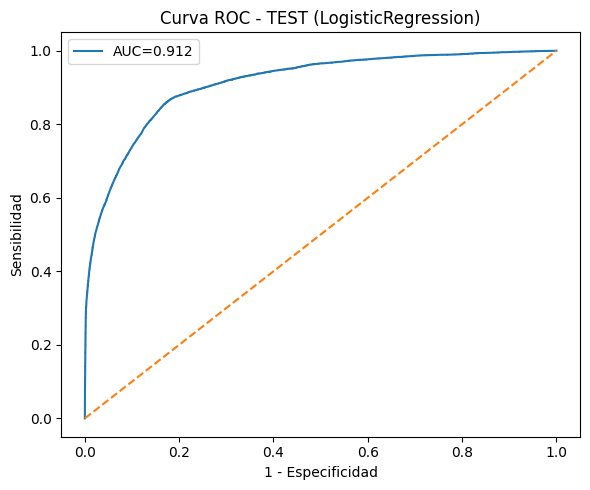

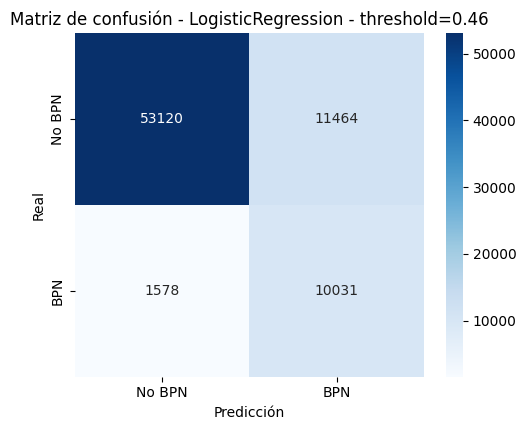


=== INTERCEPTO ===
0.2244

=== TOP 20 COEFICIENTES Y ODDS RATIOS ===
                                             variable    beta  odds_ratio
0                               num__TIEMPO_GESTACION -2.0813      0.1248
1                  cat__MULTIPLICIDAD_AGRUPADA_Simple -1.0426      0.3525
2                        cat__SEXO_AGRUPADO_MASCULINO -0.4619      0.6301
3          cat__REGIMEN_SEGURIDAD_AGRUPADO_Subsidiado  0.1217      1.1295
4        cat__NIVEL_EDUCATIVO_MADRE_AGRUPADO_Posgrado -0.1207      0.8863
5                        num__NUM_HIJOS_NACIDOS_VIVOS -0.1188      0.8880
6        cat__NIVEL_EDUCATIVO_MADRE_AGRUPADO_Superior -0.0977      0.9070
7                          cat__AREA_NACIMIENTO_Norte -0.0918      0.9123
8                                  num__NUM_EMBARAZOS -0.0789      0.9241
9            cat__ESTADO_CONYUGAL_AGRUPADO_Sin pareja  0.0621      1.0640
10              cat__AREA_RESIDENCIA_MADRE_Suroriente  0.0603      1.0622
11       cat__NIVEL_EDUCATIVO_PADRE_AGRUPA

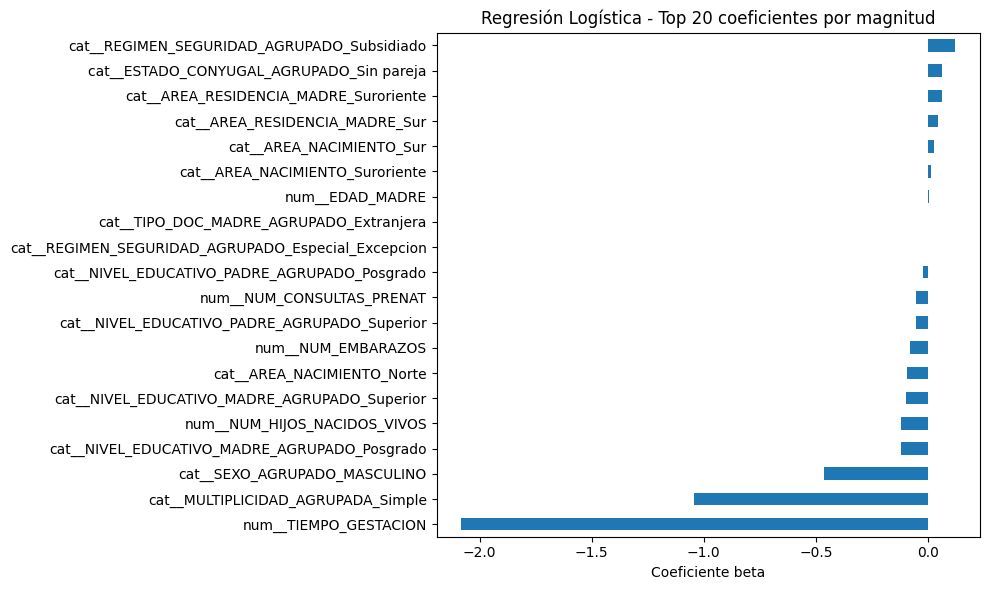

<Figure size 1000x600 with 0 Axes>

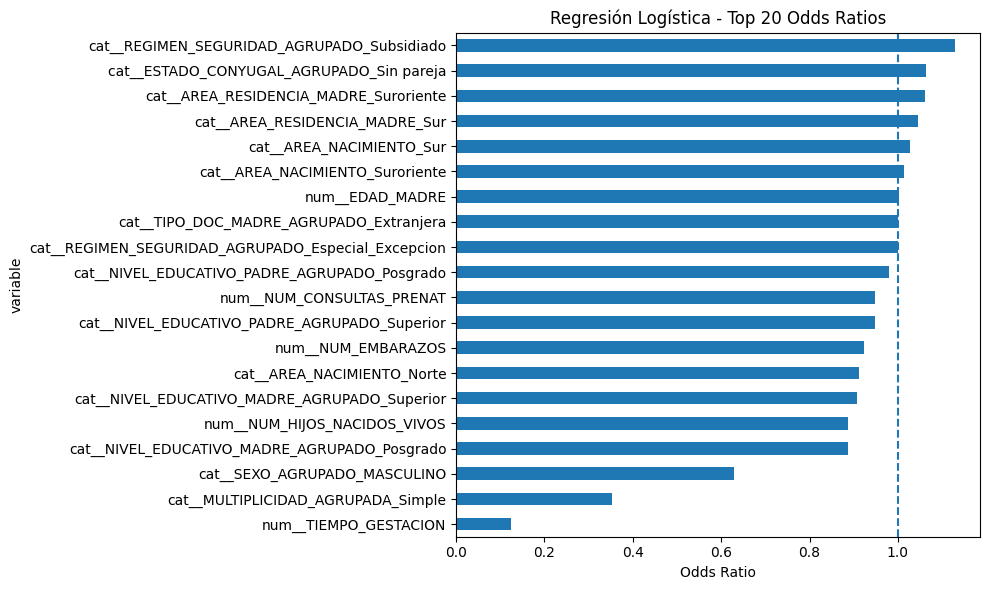

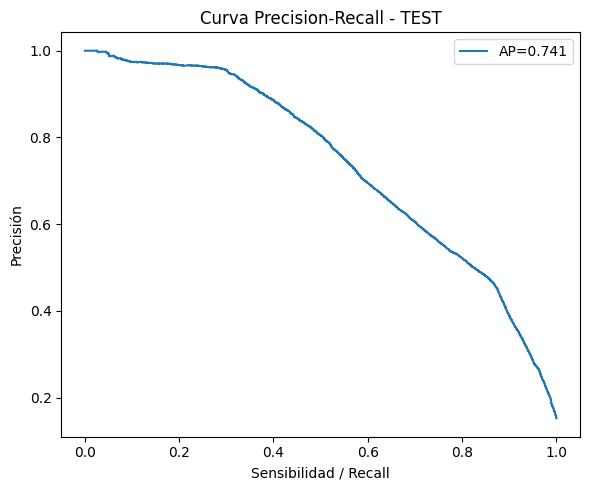

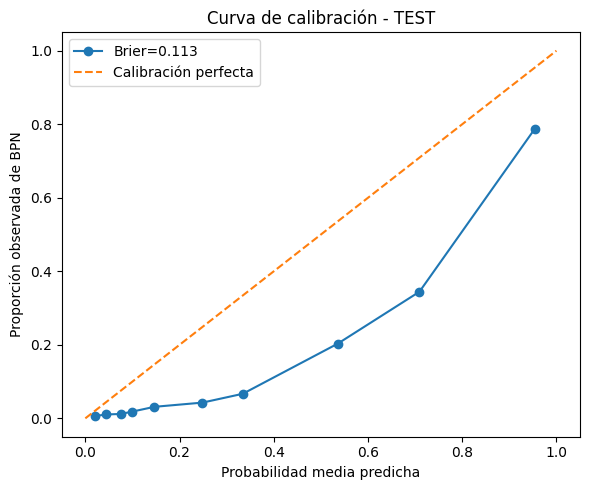


=== COMPARACIÓN TRAIN_DEV vs TEST ===
    Conjunto  Threshold     AUC  AveragePrecision      F1      F2  \
0  TRAIN_DEV       0.46  0.9142            0.7424  0.6067  0.7394   
1       TEST       0.46  0.9124            0.7406  0.6060  0.7383   

   Sensibilidad  Precision   Brier  
0        0.8657     0.4669  0.1124  
1        0.8641     0.4667  0.1130  


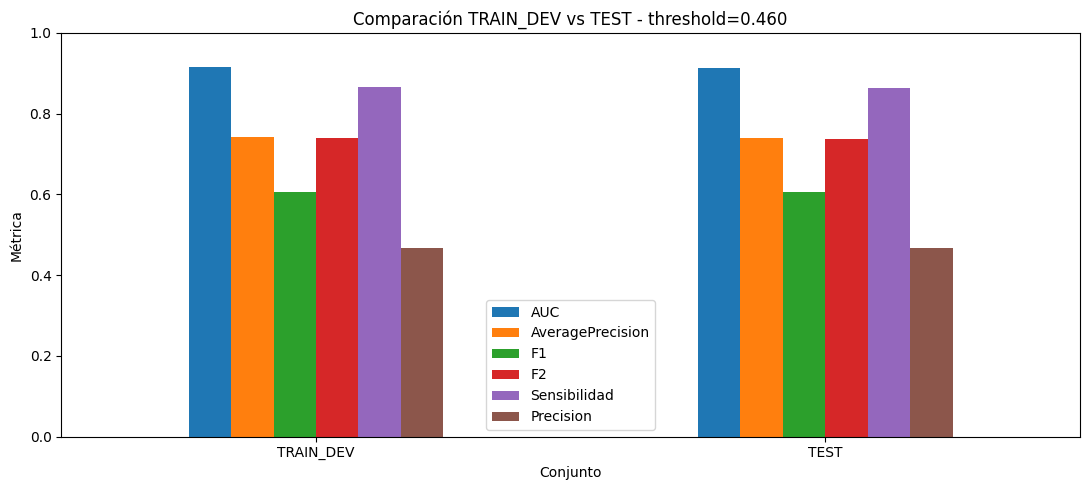

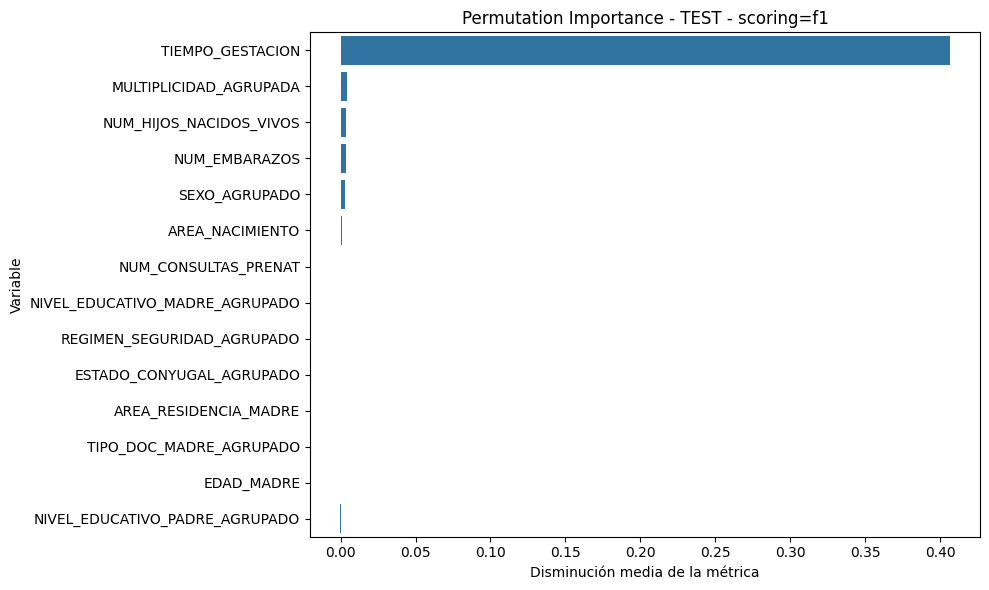

,variable,beta,odds_ratio
0,num__TIEMPO_GESTACION,-2.081293,0.124769
1,cat__MULTIPLICIDAD_AGRUPADA_Simple,-1.042569,0.352548
2,cat__SEXO_AGRUPADO_MASCULINO,-0.461949,0.630054
3,cat__REGIMEN_SEGURIDAD_AGRUPADO_Subsidiado,0.121731,1.129451
4,cat__NIVEL_EDUCATIVO_MADRE_AGRUPADO_Posgrado,-0.120685,0.886313
5,num__NUM_HIJOS_NACIDOS_VIVOS,-0.118770,0.888012
6,cat__NIVEL_EDUCATIVO_MADRE_AGRUPADO_Superior,-0.097668,0.906950
7,cat__AREA_NACIMIENTO_Norte,-0.091803,0.912285
8,num__NUM_EMBARAZOS,-0.078949,0.924087
9,cat__ESTADO_CONYUGAL_AGRUPADO_Sin pareja,0.062066,1.064033


In [9]:
logreg_bpn = OptunaLogRegSelectorV2(
    df=datos,
    target=target_bpn,
    features=features_bpn,
    numeric_vars=numeric_vars_bpn,
    dummy_vars=dummy_vars_bpn,
    dropna=True,
    clip_outliers=False,
    test_size=0.2,
    random_state=42
)

logreg_bpn.optimizar(
    n_trials=15,
    metrica_objetivo="f2",
    threshold_min=0.05,
    threshold_max=0.80,
    threshold_step=0.01,
    n_splits=5
)

logreg_bpn.entrenar_y_evaluar()
logreg_bpn.evaluar_train_vs_test()
logreg_bpn.importancia_permutacion_test(scoring="f1")
logreg_bpn.tabla_odds_ratios(top_n=30)

# Resultados del Modelo de Regresión Logística para Predicción de Bajo Peso al Nacer (BPN)

## Métrica objetivo y configuración óptima

El modelo fue optimizado utilizando como métrica objetivo el **F2-Score**, priorizando la sensibilidad (recall) sobre la precisión, debido a que en un contexto de salud pública y tamizaje clínico resulta más costoso no identificar un recién nacido con bajo peso al nacer que generar algunos falsos positivos.

La configuración óptima encontrada mediante Optuna fue:

* **Modelo:** Regresión Logística Penalizada.
* **Penalty:** L1 (Lasso).
* **Solver:** Saga.
* **C:** 0.0033.
* **Class Weight:** Balanced.
* **Sampler:** None.
* **Threshold óptimo:** 0.46.

Un hallazgo importante es que el algoritmo no requirió técnicas de remuestreo (SMOTE, ADASYN, UnderSampling, etc.), indicando que el desbalance observado (≈15.2% de casos BPN) pudo ser manejado adecuadamente mediante ponderación de clases (`class_weight='balanced'`).

---

# Desempeño en Validación Cruzada

## Promedio de métricas CV

| Métrica      | Valor |
| ------------ | ----- |
| Threshold    | 0.464 |
| F1           | 0.608 |
| F2           | 0.740 |
| AUC          | 0.914 |
| Sensibilidad | 0.866 |
| Precisión    | 0.468 |

Estos resultados muestran una capacidad discriminativa excelente y una elevada capacidad para identificar casos positivos.

---

# Desempeño en Test

## Métricas de evaluación final

| Métrica           | Train Dev | Test   |
| ----------------- | --------- | ------ |
| AUC               | 0.9142    | 0.9124 |
| Average Precision | 0.7424    | 0.7406 |
| F1                | 0.6067    | 0.6060 |
| F2                | 0.7394    | 0.7383 |
| Sensibilidad      | 0.8657    | 0.8641 |
| Precisión         | 0.4669    | 0.4667 |
| Brier Score       | 0.1124    | 0.1130 |

## Interpretación

La similitud entre las métricas obtenidas en entrenamiento y prueba indica:

* Ausencia de sobreajuste (overfitting).
* Buena capacidad de generalización.
* Estabilidad del proceso de validación cruzada.
* Ausencia de evidencia de fuga de información (data leakage).

Particularmente, la diferencia entre AUC, F2 y Sensibilidad en Train y Test es mínima, lo que sugiere que el desempeño observado es robusto y reproducible.

---

# Interpretación de la Matriz de Confusión

## Matriz de Confusión (Test)

|             | Predicción No BPN | Predicción BPN |
| ----------- | ----------------- | -------------- |
| Real No BPN | 53,120            | 11,464         |
| Real BPN    | 1,578             | 10,031         |

### Interpretación

* **Verdaderos Positivos (TP):** 10,031 recién nacidos con BPN fueron correctamente identificados.
* **Verdaderos Negativos (TN):** 53,120 recién nacidos sin BPN fueron correctamente clasificados.
* **Falsos Positivos (FP):** 11,464 recién nacidos fueron clasificados como BPN sin serlo realmente.
* **Falsos Negativos (FN):** 1,578 recién nacidos con BPN no fueron detectados por el modelo.

### Hallazgo principal

El modelo logra detectar aproximadamente:

$$
\frac{10031}{10031+1578}=0.864
$$

es decir, **86.4% de todos los casos reales de bajo peso al nacer**, lo que representa una capacidad de detección elevada para fines de vigilancia o tamizaje.

---

# Principales Hallazgos de Interpretabilidad

La regularización L1 produjo un modelo parsimonioso, reteniendo únicamente las variables más informativas.

## Variables con mayor influencia

### 1. Tiempo de gestación

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -2.081      | 0.125      |

#### Interpretación

Es la variable más influyente del modelo.

Por cada incremento en el tiempo de gestación, las probabilidades de presentar bajo peso al nacer disminuyen considerablemente.

Un Odds Ratio de 0.125 indica una fuerte asociación protectora, consistente con la evidencia clínica que relaciona la prematurez con el bajo peso al nacer.

---

### 2. Multiplicidad del embarazo (Simple)

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -1.043      | 0.352      |

#### Interpretación

Los embarazos simples presentan menor probabilidad de bajo peso al nacer en comparación con embarazos múltiples.

Este resultado es consistente con la literatura obstétrica, donde los embarazos gemelares o múltiples presentan un riesgo significativamente mayor de restricción del crecimiento fetal y prematurez.

---

### 3. Sexo masculino

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -0.462      | 0.630      |

#### Interpretación

Los recién nacidos masculinos presentan menor probabilidad de bajo peso al nacer respecto a la categoría de referencia.

Aunque el efecto es moderado, constituye una variable relevante dentro del modelo.

---

### 4. Régimen subsidiado

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| 0.122       | 1.130      |

#### Interpretación

Se observa un incremento moderado en el riesgo relativo de bajo peso al nacer respecto al régimen de referencia.

Esto podría estar reflejando diferencias socioeconómicas, acceso a servicios de salud o condiciones asociadas a vulnerabilidad social.

---

### 5. Número de hijos nacidos vivos

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -0.119      | 0.888      |

#### Interpretación

Existe evidencia de un efecto protector moderado asociado a una mayor experiencia reproductiva de la madre.

---

# Interpretación de la Regularización

El valor óptimo encontrado para:

$$
C=0.0033
$$

es extremadamente pequeño.

Dado que:

$$
C=\frac{1}{\lambda}
$$

esto implica una penalización fuerte sobre los coeficientes.

### Consecuencias

* Modelo más estable.
* Menor varianza.
* Menor riesgo de sobreajuste.
* Mayor capacidad de generalización.
* Selección automática de variables relevantes.

---

# Conclusión Técnica

El modelo de regresión logística presentó un desempeño sobresaliente para la predicción de bajo peso al nacer, alcanzando una capacidad discriminativa excelente (AUC ≈ 0.91) y una sensibilidad cercana al 86%, lo que permite identificar la gran mayoría de los casos positivos. La estabilidad observada entre validación cruzada y conjunto de prueba sugiere que el modelo generaliza adecuadamente y no presenta evidencia de sobreajuste.

Desde la perspectiva clínica y epidemiológica, los principales determinantes identificados fueron el tiempo de gestación, la multiplicidad del embarazo y variables sociodemográficas relacionadas con condiciones maternas. Adicionalmente, la regularización L1 seleccionada por Optuna produjo un modelo parsimonioso, interpretable y robusto, características altamente deseables para aplicaciones en salud pública. En consecuencia, este modelo constituye una línea base sólida y metodológicamente válida frente a la cual deberán compararse los modelos más complejos como Random Forest y XGBoost.


In [15]:
logreg_bpn.best_pipeline_

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('escalador',
                                                                   StandardScaler())]),
                                                  ['TIEMPO_GESTACION',
                                                   'NUM_HIJOS_NACIDOS_VIVOS',
                                                   'NUM_EMBARAZOS',
                                                   'EDAD_MADRE',
                                                   'NUM_CONSULTAS_PRENAT']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['MULTIPLICIDAD_AGRUPADA',
                                                   'SEXO_AGRUPADO',
                                                   'NIVEL_EDUCATIVO_...
                                                   'NIVEL_EDUCATIVO_PADRE_AGRUPADO',
                                                   'REGIMEN_SEGURIDAD_AGRUPADO',
                                                   'TIPO_DOC_MADRE_AGRUPADO',
                                                   'AREA_RESIDENCIA_MADRE',
                                                   'AREA_NACIMIENTO',
                                                   'ESTADO_CONYUGAL_AGRUPADO']),
                                                 ('passthrough', 'passthrough',
                                                  [])])),
                ('sampler', 'passthrough'),
                ('model',
                 LogisticRegression(C=0.0032687254098544157,
                                    class_weight='balanced', max_iter=5000,
                                    penalty='l1', random_state=42,
                                    solver='saga'))])

# Resultados del Modelo de Regresión Logística para Predicción de Bajo Peso al Nacer (BPN)

## Métrica objetivo y configuración óptima

El modelo fue optimizado utilizando como métrica objetivo el **F2-Score**, priorizando la sensibilidad (recall) sobre la precisión, debido a que en un contexto de salud pública y tamizaje clínico resulta más costoso no identificar un recién nacido con bajo peso al nacer que generar algunos falsos positivos.

La configuración óptima encontrada mediante Optuna fue:

* **Modelo:** Regresión Logística Penalizada.
* **Penalty:** L1 (Lasso).
* **Solver:** Saga.
* **C:** 0.0033.
* **Class Weight:** Balanced.
* **Sampler:** None.
* **Threshold óptimo:** 0.46.

Un hallazgo importante es que el algoritmo no requirió técnicas de remuestreo (SMOTE, ADASYN, UnderSampling, etc.), indicando que el desbalance observado (≈15.2% de casos BPN) pudo ser manejado adecuadamente mediante ponderación de clases (`class_weight='balanced'`).

---

# Desempeño en Validación Cruzada

## Promedio de métricas CV

| Métrica      | Valor |
| ------------ | ----- |
| Threshold    | 0.464 |
| F1           | 0.608 |
| F2           | 0.740 |
| AUC          | 0.914 |
| Sensibilidad | 0.866 |
| Precisión    | 0.468 |

Estos resultados muestran una capacidad discriminativa excelente y una elevada capacidad para identificar casos positivos.

---

# Desempeño en Test

## Métricas de evaluación final

| Métrica           | Train Dev | Test   |
| ----------------- | --------- | ------ |
| AUC               | 0.9142    | 0.9124 |
| Average Precision | 0.7424    | 0.7406 |
| F1                | 0.6067    | 0.6060 |
| F2                | 0.7394    | 0.7383 |
| Sensibilidad      | 0.8657    | 0.8641 |
| Precisión         | 0.4669    | 0.4667 |
| Brier Score       | 0.1124    | 0.1130 |

## Interpretación

La similitud entre las métricas obtenidas en entrenamiento y prueba indica:

* Ausencia de sobreajuste (overfitting).
* Buena capacidad de generalización.
* Estabilidad del proceso de validación cruzada.
* Ausencia de evidencia de fuga de información (data leakage).

Particularmente, la diferencia entre AUC, F2 y Sensibilidad en Train y Test es mínima, lo que sugiere que el desempeño observado es robusto y reproducible.

---

# Interpretación de la Matriz de Confusión

## Matriz de Confusión (Test)

|             | Predicción No BPN | Predicción BPN |
| ----------- | ----------------- | -------------- |
| Real No BPN | 53,120            | 11,464         |
| Real BPN    | 1,578             | 10,031         |

### Interpretación

* **Verdaderos Positivos (TP):** 10,031 recién nacidos con BPN fueron correctamente identificados.
* **Verdaderos Negativos (TN):** 53,120 recién nacidos sin BPN fueron correctamente clasificados.
* **Falsos Positivos (FP):** 11,464 recién nacidos fueron clasificados como BPN sin serlo realmente.
* **Falsos Negativos (FN):** 1,578 recién nacidos con BPN no fueron detectados por el modelo.

### Hallazgo principal

El modelo logra detectar aproximadamente:

$$
\frac{10031}{10031+1578}=0.864
$$

es decir, **86.4% de todos los casos reales de bajo peso al nacer**, lo que representa una capacidad de detección elevada para fines de vigilancia o tamizaje.

---

# Principales Hallazgos de Interpretabilidad

La regularización L1 produjo un modelo parsimonioso, reteniendo únicamente las variables más informativas.

## Variables con mayor influencia

### 1. Tiempo de gestación

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -2.081      | 0.125      |

#### Interpretación

Es la variable más influyente del modelo.

Por cada incremento en el tiempo de gestación, las probabilidades de presentar bajo peso al nacer disminuyen considerablemente.

Un Odds Ratio de 0.125 indica una fuerte asociación protectora, consistente con la evidencia clínica que relaciona la prematurez con el bajo peso al nacer.

---

### 2. Multiplicidad del embarazo (Simple)

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -1.043      | 0.352      |

#### Interpretación

Los embarazos simples presentan menor probabilidad de bajo peso al nacer en comparación con embarazos múltiples.

Este resultado es consistente con la literatura obstétrica, donde los embarazos gemelares o múltiples presentan un riesgo significativamente mayor de restricción del crecimiento fetal y prematurez.

---

### 3. Sexo masculino

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -0.462      | 0.630      |

#### Interpretación

Los recién nacidos masculinos presentan menor probabilidad de bajo peso al nacer respecto a la categoría de referencia.

Aunque el efecto es moderado, constituye una variable relevante dentro del modelo.

---

### 4. Régimen subsidiado

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| 0.122       | 1.130      |

#### Interpretación

Se observa un incremento moderado en el riesgo relativo de bajo peso al nacer respecto al régimen de referencia.

Esto podría estar reflejando diferencias socioeconómicas, acceso a servicios de salud o condiciones asociadas a vulnerabilidad social.

---

### 5. Número de hijos nacidos vivos

| Coeficiente | Odds Ratio |
| ----------- | ---------- |
| -0.119      | 0.888      |

#### Interpretación

Existe evidencia de un efecto protector moderado asociado a una mayor experiencia reproductiva de la madre.

---

# Interpretación de la Regularización

El valor óptimo encontrado para:

$$
C=0.0033
$$

es extremadamente pequeño.

Dado que:

$$
C=\frac{1}{\lambda}
$$

esto implica una penalización fuerte sobre los coeficientes.

### Consecuencias

* Modelo más estable.
* Menor varianza.
* Menor riesgo de sobreajuste.
* Mayor capacidad de generalización.
* Selección automática de variables relevantes.

---

# Conclusión Técnica

El modelo de regresión logística presentó un desempeño sobresaliente para la predicción de bajo peso al nacer, alcanzando una capacidad discriminativa excelente (AUC ≈ 0.91) y una sensibilidad cercana al 86%, lo que permite identificar la gran mayoría de los casos positivos. La estabilidad observada entre validación cruzada y conjunto de prueba sugiere que el modelo generaliza adecuadamente y no presenta evidencia de sobreajuste.

Desde la perspectiva clínica y epidemiológica, los principales determinantes identificados fueron el tiempo de gestación, la multiplicidad del embarazo y variables sociodemográficas relacionadas con condiciones maternas. Adicionalmente, la regularización L1 seleccionada por Optuna produjo un modelo parsimonioso, interpretable y robusto, características altamente deseables para aplicaciones en salud pública. En consecuencia, este modelo constituye una línea base sólida y metodológicamente válida frente a la cual deberán compararse los modelos más complejos como Random Forest y XGBoost.


## **Random forest**

In [14]:
rf_bpn = OptunaRFSelectorV2(
    df=datos,
    target=target_bpn,
    features=features_bpn,
    numeric_vars=numeric_vars_bpn,
    dummy_vars=dummy_vars_bpn,
    dropna=True,
    clip_outliers=False,
    test_size=0.2,
    random_state=42
)

rf_bpn.optimizar(
    n_trials=15,
    metrica_objetivo="f2",
    threshold_min=0.05,
    threshold_max=0.80,
    threshold_step=0.01,
    n_splits=5
)

rf_bpn.entrenar_y_evaluar()
rf_bpn.evaluar_train_vs_test()
rf_bpn.importancia_permutacion_test(scoring="f1")

[I 2026-06-09 16:55:34,093] A new study created in memory with name: no-name-4279b2d8-5c05-4297-a623-97507a27cc69



=== SPLIT INICIAL ===
Train_dev: (304769, 14)
Test     : (76193, 14)
Prevalencia global    : 0.1524
Prevalencia train_dev : 0.1524
Prevalencia test      : 0.1524


[I 2026-06-09 16:56:28,909] Trial 0 finished with value: 0.7402230124773551 and parameters: {'sampler': 'undersample', 'sampling_strategy': 0.6808920093945671, 'n_estimators': 625, 'max_depth': 3, 'min_samples_split': 30, 'min_samples_leaf': 25, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7402230124773551.
[I 2026-06-09 17:25:15,253] Trial 1 finished with value: 0.7395597395195923 and parameters: {'sampler': 'borderlinesmote', 'sampling_strategy': 0.6113875507308892, 'n_estimators': 556, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 6, 'max_features': None, 'class_weight': None}. Best is trial 0 with value: 0.7402230124773551.
[W 2026-06-09 17:35:47,258] Trial 2 failed with parameters: {'sampler': 'smotetomek', 'sampling_strategy': 0.4493688608715288, 'n_estimators': 512, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 30, 'max_features': 'log2', 'class_weight': 'balanced'} because of the following error: KeyboardInterr

KeyboardInterrupt: 